In [ ]:
!pip install scikit_posthocs


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

c:\Users\JAOF-PC\Documents\Development\Meta-Learning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: Obter conjunto de datasets de treinamento

In [ ]:
#Carregando os datasets
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3',
         'qsar', 'solar-flare']

#Errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {}
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')


Fetching dataset: diabetes
Fetching dataset: blood-transfusion-service-center
Fetching dataset: monks-problems-2
Fetching dataset: tic-tac-toe
Fetching dataset: titanic
Fetching dataset: pc1
Fetching dataset: kr-vs-kp
Fetching dataset: phoneme
Fetching dataset: wdbc
Fetching dataset: semeion
Fetching dataset: isolet


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name blood-transfusion-service-center exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1464
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46913

  warn(warning_msg)
/opt/homebre

Fetching dataset: cnae-9
Fetching dataset: ilpd-numeric
Fetching dataset: students_scores
Fetching dataset: usps


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name cnae-9 exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1468
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41967

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ilpd-numeric exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=41943
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41945

  warn(warning_msg)
/opt/homebrew/Caskroom/minicond

Fetching dataset: ibm-employee-performance
Fetching dataset: mushroom
Fetching dataset: segment
Fetching dataset: autoUniv-au1-1000
Fetching dataset: pizzacutter3
Fetching dataset: qsar
Fetching dataset: solar-flare
Finished fetching 22 datasets.


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ibm-employee-performance exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43895
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43897

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name mushroom exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=24
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=43922

  warn(warning_msg)
/opt/homebrew/Caskr

## Passo 2: Avaliar performance dos classificadores nos datasets

In [ ]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name in names:
    print(f'Processing dataset: {dataset_name}')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')

        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy',
                                    return_train_score=False)

        # Extract fold accuracies
        fold_accs = cv_results['test_score']

        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }

        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: diabetes
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: blood-transfusion-service-center
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: monks-problems-2
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: tic-tac-toe
Falling back to simple imputation strategy.
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: titanic
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: pc1
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

...

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: autoUniv-au1-1000
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: pizzacutter3
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to s

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: qsar
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: solar-flare
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done


In [ ]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [ ]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


## Passo 3: Extrair meta-features dos datasets

In [ ]:
# Extract meta-features
meta_features = []

for dataset_name in names:
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)

    # Extract meta-features
    try:
        mfe = MFE(groups=["general", "statistical", "info-theory",
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()

        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}

        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from diabetes... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


Done
Extracting meta-features from blood-transfusion-service-center... Done
Extracting meta-features from monks-problems-2... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1271: RuntimeWarning: invalid value encountered in log
  * np.log(np.linalg.det(pooled_cov_mat))


Done
Extracting meta-features from tic-tac-toe... 

...

Done
Extracting meta-features from qsar... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'g_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: The harmonic mean is only defined if all elements are non-negative; otherwise, the result is NaN.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'h_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt

Done
Extracting meta-features from solar-flare... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: divide by zero encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices


Done


In [ ]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [ ]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [ ]:
meta_features_df

,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,cov.mean,...,sd.mean,sd_ratio,sil,skewness.mean,sparsity.mean,t_mean.mean,var.mean,vdb,vdu,w_lambda
diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,1.093502e+02,...,25.733743,1.032594,0.104260,0.527181,0.015923,40.209208,1.893059e+03,4.427474,3.677824e-08,6.967469e-01
blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,5.568267e+03,...,374.534549,1.082778,0.178546,2.254043,0.025118,267.449444,5.329470e+05,2.841441,0.000000e+00,8.709436e-01
monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,8.194676e-03,...,0.759888,NaN,-0.001832,-0.003244,0.373958,1.915974,6.221104e-01,16.096022,2.562547e-06,9.804071e-01
tic-tac-toe,0.014676,1.538037,0.009395,0.966025,NaN,19.371543,0.015851,0.930954,0.125923,2.937108e-02,...,0.481048,NaN,0.023668,0.524541,0.332637,0.294042,2.317603e-01,6.684681,2.083475e-06,6.679638e-02
titanic,0.054809,0.958873,0.001363,0.470040,0.0,236.113508,0.080603,0.907651,0.185447,1.856629e-01,...,1.000460,NaN,0.234431,0.683594,0.416402,0.151765,1.000920e+00,2.585854,0.000000e+00,7.790622e-01
pc1,0.216429,2.937619,0.018936,0.386223,0.0,15.547851,0.006607,0.363800,0.632733,9.113908e+06,...,8678.609589,NaN,0.620808,7.986854,0.012637,266.343759,1.391022e+09,2.173658,0.000000e+00,8.508315e-01
kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,1.123369e-02,...,0.332009,NaN,0.031625,4.108820,0.495212,0.224809,1.303675e-01,5.676987,8.009382e-08,3.602836e-01
phoneme,0.057846,4.025713,0.000925,0.497794,0.0,408.510486,0.010767,0.873182,0.126089,1.260889e-01,...,1.000000,1.234492,0.087266,0.779033,0.000010,-0.151914,1.000000e+00,3.102294,5.578544e-10,7.522012e-01
wdbc,0.052249,2.999956,0.052724,0.879957,0.0,633.631104,0.051585,0.952635,0.394897,6.764651e+02,...,34.904719,NaN,0.513697,1.731241,0.000209,53.294606,1.506322e+04,0.720645,3.317102e-08,2.256753e-01
semeion,0.031348,0.875007,0.160703,0.788536,0.0,41.251899,0.188329,3.321819,0.096662,2.013985e-02,...,0.455351,NaN,0.049640,0.807858,0.499686,0.222550,2.092574e-01,3.661805,1.756471e-05,3.074668e-05


# Passo 4: Combinar as meta-features e as performances

In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


In [ ]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [ ]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df,
    left_on='Dataset',
    right_index=True,
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [ ]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,var.mean,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,2.366491e-01,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,5.329470e+05,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,8.251032e-03,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,1.893059e+03,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,2.222840e+06,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,1.761536e+04,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,1.862294e-01,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,1.303675e-01,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,6.221104e-01,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,9.336038e-02,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [ ]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [ ]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree


In [ ]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
MLP,6
DecisionTree,6
LogisticRegression,5
SVM,4
KNN,1


# Passo 5: Treinar (e avaliar) o meta-modelo

In [ ]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []
meta_model_train_time = 0.0
meta_model_test_time = 0.0

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train)
    meta_model_train_time += time() - t0

    # Predict the best classifier for the test dataset
    t0 = time()
    y_pred.append(clf.predict(X_test)[0])
    meta_model_test_time += time() - t0

    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics
meta_model_base_perf = summary_df['Perf of best clf (pred)'].mean()
meta_model_accuracy = accuracy_score(y_true, y_pred)
meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')
print(f'Training time (s): {meta_model_train_time:.4f}')
print(f'Testing time (s): {meta_model_test_time:.4f}')
print(f'Base perf: {meta_model_base_perf:.4f}')


Meta-model Accuracy: 0.23
Meta-model F1-score: 0.22
Training time (s): 0.0889
Testing time (s): 0.0423
Base perf: 0.8542


In [ ]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.651000
1,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,DecisionTree,0.700433
4,ibm-employee-performance,DecisionTree,1.000000,LogisticRegression,0.961224
5,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,MLP,0.961396,SVM,0.961139
7,kr-vs-kp,DecisionTree,0.995620,MLP,0.993742
8,monks-problems-2,DecisionTree,0.991667,MLP,0.750441
9,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


In [ ]:
# Base-level performance:
summary_df.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.854170
std,0.094263,0.107603
min,0.718700,0.651000
25%,0.812109,0.756007
50%,0.925093,0.866407
75%,0.963726,0.955594
max,1.000000,1.000000


In [ ]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop])
final_summary

,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM,0.758000,DecisionTree,0.651000
1,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression,0.772707,LogisticRegression,0.772707
2,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP,0.955556,DecisionTree,0.864815
3,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression,0.770792,DecisionTree,0.700433
4,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree,1.000000,LogisticRegression,0.961224
5,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression,0.718700,LogisticRegression,0.718700
6,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP,0.961396,SVM,0.961139
7,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree,0.995620,MLP,0.993742
8,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree,0.991667,MLP,0.750441
9,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree,1.000000,DecisionTree,1.000000


<Axes: >

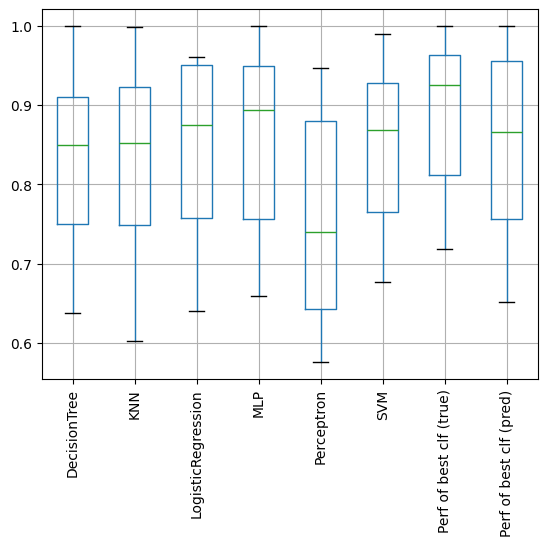

In [ ]:
final_summary.boxplot(rot=90)

# Passo 6: Treinar (e Avaliar) o modelo usando Rankings

## Passo 6.1: Abordagem 1

In [ ]:
# Create a dictionary to store the results
summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_best = []
y_pred_best = []
rank_ab1_train_time = 0.0
rank_ab1_test_time = 0.0
rank_ab1_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset[classifier_cols]  # multi-output regression target (one score per classifier)

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train regressor to predict classifier performances
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train)
    rank_ab1_train_time += time() - t0

    # Predicted performances for each classifier on the test dataset
    t0 = time()
    pred_scores = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_scores.idxmax()
    rank_ab1_test_time += time() - t0

    # True performances for each classifier on the test dataset
    true_scores = y_test.iloc[0]
    true_best_clf = true_scores.idxmax()

    # Spearman rank correlation (SRC) between predicted and true classifier score vectors
    fold_src = pred_scores.corr(true_scores, method='spearman')
    rank_ab1_src_values.append(fold_src)

    y_true_best.append(true_best_clf)
    y_pred_best.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    summary_of_predictions['Dataset'].append(dataset_name)
    summary_of_predictions['Best clf (true)'].append(true_best_clf)
    summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    # performance obtained by selecting the predicted best classifier
    summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

# Create a DataFrame from the summary of predictions
rank_ab1_summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics over predicted best-classifier labels
rank_ab1_base_perf = rank_ab1_summary_df['Perf of best clf (pred)'].mean()
rank_ab1_meta_model_accuracy = accuracy_score(y_true_best, y_pred_best)
rank_ab1_meta_model_f1 = f1_score(y_true_best, y_pred_best, average='weighted')
rank_ab1_src = np.nanmean(rank_ab1_src_values)
print(f'Meta-model Accuracy: {rank_ab1_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {rank_ab1_meta_model_f1:.2f}')
print(f'Training time (s): {rank_ab1_train_time:.4f}')
print(f'Testing time (s): {rank_ab1_test_time:.4f}')
print(f'Base perf: {rank_ab1_base_perf:.4f}')
print(f'SRC: {rank_ab1_src:.4f}')

Meta-model Accuracy: 0.23
Meta-model F1-score: 0.22
Training time (s): 0.1098
Testing time (s): 0.0513
Base perf: 0.8385
SRC: 0.3761


In [ ]:
rank_ab1_summary_df.describe()

,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.838456
std,0.094263,0.112997
min,0.718700,0.673249
25%,0.812109,0.740529
50%,0.925093,0.862265
75%,0.963726,0.949047
max,1.000000,0.995620


## Passo 6.2: Abordagem 2

In [ ]:
# Create a dictionary to store the results
summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_best = []
y_pred_best = []
rank_ab2_train_time = 0.0
rank_ab2_test_time = 0.0
rank_ab2_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)

    # Raw classifier performances (for reporting obtained performance)
    y_raw = meta_dataset[classifier_cols]

    # Convert classifier performances to ranks per dataset (1 = best classifier)
    y_rank = y_raw.rank(axis=1, ascending=False, method='average')

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_rank = y_rank.iloc[train_index]
    y_test_rank = y_rank.iloc[test_index]
    y_test_raw = y_raw.iloc[test_index]

    # Train regressor to predict classifier ranks
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train_rank)
    rank_ab2_train_time += time() - t0

    # Predicted ranks for each classifier on the test dataset
    t0 = time()
    pred_ranks = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_ranks.idxmin()
    rank_ab2_test_time += time() - t0

    # True ranks for each classifier on the test dataset
    true_ranks = y_test_rank.iloc[0]
    true_best_clf = true_ranks.idxmin()
    true_scores = y_test_raw.iloc[0]

    # Spearman rank correlation (SRC) between predicted and true rank vectors
    fold_src = pred_ranks.corr(true_ranks, method='spearman')
    rank_ab2_src_values.append(fold_src)

    y_true_best.append(true_best_clf)
    y_pred_best.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    summary_of_predictions['Dataset'].append(dataset_name)
    summary_of_predictions['Best clf (true)'].append(true_best_clf)
    summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

# Create a DataFrame from the summary of predictions
rank_ab2_summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics over predicted best-classifier labels
rank_ab2_base_perf = rank_ab2_summary_df['Perf of best clf (pred)'].mean()
rank_ab2_meta_model_accuracy = accuracy_score(y_true_best, y_pred_best)
rank_ab2_meta_model_f1 = f1_score(y_true_best, y_pred_best, average='weighted')
rank_ab2_src = np.nanmean(rank_ab2_src_values)
print(f'Meta-model Accuracy (rank target): {rank_ab2_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score (rank target): {rank_ab2_meta_model_f1:.2f}')
print(f'Training time (s): {rank_ab2_train_time:.4f}')
print(f'Testing time (s): {rank_ab2_test_time:.4f}')
print(f'Base perf: {rank_ab2_base_perf:.4f}')
print(f'SRC: {rank_ab2_src:.4f}')

rank_ab2_summary_df.describe()

Meta-model Accuracy (rank target): 0.23
Meta-model F1-score (rank target): 0.23
Training time (s): 0.1142
Testing time (s): 0.0536
Base perf: 0.8436
SRC: 0.4106


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.843604
std,0.094263,0.112140
min,0.718700,0.651000
25%,0.812109,0.756984
50%,0.925093,0.861027
75%,0.963726,0.947348
max,1.000000,1.000000


# Passo 7: Comparar Resultados

In [ ]:
comparison_table = pd.DataFrame([
    {
        'Model': "Decision Tree (Classification)",
        'Base perf': meta_model_base_perf,
        'Acc': meta_model_accuracy,
        'F1': meta_model_f1,
        'SRC': np.nan,
        'Training time (s)': meta_model_train_time,
        'Testing time (s)': meta_model_test_time,
    },
    {
        'Model': "Decision Tree Rank (Regression on performance)",
        'Base perf': rank_ab1_base_perf,
        'Acc': rank_ab1_meta_model_accuracy,
        'F1': rank_ab1_meta_model_f1,
        'SRC': rank_ab1_src,
        'Training time (s)': rank_ab1_train_time,
        'Testing time (s)': rank_ab1_test_time,
    },
    {
        'Model': "Decision Tree Rank (Regression on ranks)",
        'Base perf': rank_ab2_base_perf,
        'Acc': rank_ab2_meta_model_accuracy,
        'F1': rank_ab2_meta_model_f1,
        'SRC': rank_ab2_src,
        'Training time (s)': rank_ab2_train_time,
        'Testing time (s)': rank_ab2_test_time,
    },
])

comparison_table[['Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)']] = comparison_table[
    ['Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)']
] .round(4)

comparison_table

,Model,Base perf,Acc,F1,SRC,Training time (s),Testing time (s)
0,Decision Tree (Classification),0.8542,0.2273,0.2231,NaN,0.0889,0.0423
1,Decision Tree Rank (Regression on performance),0.8385,0.2273,0.2240,0.3761,0.1098,0.0513
2,Decision Tree Rank (Regression on ranks),0.8436,0.2273,0.2271,0.4106,0.1142,0.0536


In [ ]:
# Passo 8: Matrizes para teste de normalidade

# 1) Matriz pareada para performance em nível base
# Inclui as três abordagens: DT classificação (Passo 5), Ranking Ab1 e Ranking Ab2
base_perf_matrix = (
    summary_df[['Dataset', 'Perf of best clf (pred)']]
    .rename(columns={'Perf of best clf (pred)': 'base_perf_dt'})
    .merge(
        rank_ab1_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_ab1'}),
        on='Dataset',
        how='inner'
    )
    .merge(
        rank_ab2_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_ab2'}),
        on='Dataset',
        how='inner'
    )
)

# 2) Matriz pareada para SRC por dataset (Ab1 vs Ab2)
# Assumindo que rank_ab1_src_values e rank_ab2_src_values seguem a mesma ordem de datasets dos summaries
src_matrix = rank_ab1_summary_df[['Dataset']].copy()
src_matrix['src_ab1'] = np.array(rank_ab1_src_values, dtype=float)
src_matrix = src_matrix.merge(
    rank_ab2_summary_df[['Dataset']].assign(src_ab2=np.array(rank_ab2_src_values, dtype=float)),
    on='Dataset',
    how='inner'
)

# Salvar para uso em testes de normalidade
base_perf_matrix.to_csv('normality_matrix_base_perf.csv', index=False)
src_matrix.to_csv('normality_matrix_src.csv', index=False)

print('Arquivos salvos: normality_matrix_base_perf.csv, normality_matrix_src.csv')
print(f'base_perf_matrix shape: {base_perf_matrix.shape}')
print(f'src_matrix shape: {src_matrix.shape}')

base_perf_matrix.head(), src_matrix.head()

Arquivos salvos: normality_matrix_base_perf.csv, normality_matrix_src.csv
base_perf_matrix shape: (22, 4)
src_matrix shape: (22, 3)


(                            Dataset  base_perf_dt  base_perf_ab1  \
 0                 autoUniv-au1-1000      0.651000       0.703000   
 1  blood-transfusion-service-center      0.772707       0.673942   
 2                            cnae-9      0.864815       0.864815   
 3                          diabetes      0.700433       0.770792   
 4          ibm-employee-performance      0.961224       0.961224   
 
    base_perf_ab2  
 0       0.651000  
 1       0.673942  
 2       0.955556  
 3       0.658925  
 4       0.846259  ,
                             Dataset   src_ab1   src_ab2
 0                 autoUniv-au1-1000  0.142857 -0.314286
 1  blood-transfusion-service-center  0.257143 -0.085714
 2                            cnae-9  0.085714  0.771429
 3                          diabetes  0.600000  0.314286
 4          ibm-employee-performance  0.600000 -0.085714)

In [ ]:
from scipy.stats import shapiro

alpha = 0.05

def run_shapiro_tests(df, matrix_name, id_col='Dataset', alpha=0.05):
    results = []
    numeric_cols = [
        c for c in df.columns
        if c != id_col and pd.api.types.is_numeric_dtype(df[c])
    ]

    for col in numeric_cols:
        values = df[col].dropna().astype(float)

        # Shapiro-Wilk requires at least 3 observations
        if len(values) < 3:
            results.append({
                'matrix': matrix_name,
                'variable': col,
                'n': len(values),
                'W': np.nan,
                'p_value': np.nan,
                'normal_at_0.05': np.nan,
                'decision': 'insufficient data (n < 3)'
            })
            continue

        stat, p_value = shapiro(values)
        normal = p_value >= alpha
        results.append({
            'matrix': matrix_name,
            'variable': col,
            'n': len(values),
            'W': stat,
            'p_value': p_value,
            'normal_at_0.05': normal,
            'decision': 'fail to reject H0 (normal)' if normal else 'reject H0 (not normal)'
        })

    return pd.DataFrame(results)

shapiro_base_perf = run_shapiro_tests(base_perf_matrix, 'base_perf_matrix', alpha=alpha)
shapiro_src = run_shapiro_tests(src_matrix, 'src_matrix', alpha=alpha)

print('Shapiro-Wilk normality test (alpha=0.05):')
display(shapiro_base_perf)
display(shapiro_src)

Shapiro-Wilk normality test (alpha=0.05):


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,base_perf_matrix,base_perf_dt,22,0.926005,0.101303,True,fail to reject H0 (normal)
1,base_perf_matrix,base_perf_ab1,22,0.893899,0.022486,False,reject H0 (not normal)
2,base_perf_matrix,base_perf_ab2,22,0.937720,0.177573,True,fail to reject H0 (normal)


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,src_matrix,src_ab1,22,0.90006,0.029809,False,reject H0 (not normal)
1,src_matrix,src_ab2,22,0.91920,0.073175,True,fail to reject H0 (normal)


In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp

# ── Base Performance: Friedman ──────────────────────────────
dt   = base_perf_matrix['base_perf_dt'].values
ab1  = base_perf_matrix['base_perf_ab1'].values
ab2  = base_perf_matrix['base_perf_ab2'].values

stat, p = friedmanchisquare(dt, ab1, ab2)
print(f"Friedman: stat={stat:.4f}, p={p:.4f}")

if p < 0.05:
    print("→ Significant! Running post-hoc Nemenyi...")
    nemenyi = sp.posthoc_nemenyi_friedman(
        base_perf_matrix[['base_perf_dt', 'base_perf_ab1', 'base_perf_ab2']].values
    )
    print(nemenyi)
else:
    print("→ No significant difference between approaches")

# ── SRC: Wilcoxon ───────────────────────────────────────────
src1 = src_matrix['src_ab1'].values
src2 = src_matrix['src_ab2'].values

stat, p = wilcoxon(src1, src2)
print(f"\nWilcoxon: stat={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("→ Significant difference between Ab1 and Ab2 SRC")
else:
    print("→ No significant difference in SRC between approaches")

Friedman: stat=0.5246, p=0.7693
→ No significant difference between approaches

Wilcoxon: stat=96.5000, p=0.7510
→ No significant difference in SRC between approaches


# Passo 8: Treinar e avaliar outro meta-model (SVM) e ver se os resultados se repetem

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

# SVM version of Passo 5 (classification)
svm_cls_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_cls_y_true = meta_dataset['Best'].values
svm_cls_y_pred = []
svm_cls_train_time = 0.0
svm_cls_test_time = 0.0

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Impute + scale inside each fold, then fit SVM classifier
    clf = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale')
    )
    t0 = time()
    clf.fit(X_train, y_train)
    svm_cls_train_time += time() - t0

    t0 = time()
    pred_label = clf.predict(X_test)[0]
    svm_cls_y_pred.append(pred_label)
    svm_cls_test_time += time() - t0

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    true_label = y_test.values[0]
    svm_cls_summary_of_predictions['Dataset'].append(dataset_name)
    svm_cls_summary_of_predictions['Best clf (true)'].append(true_label)
    svm_cls_summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, true_label].values[0])
    svm_cls_summary_of_predictions['Best clf (pred)'].append(pred_label)
    svm_cls_summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, pred_label].values[0])

svm_cls_summary_df = pd.DataFrame(svm_cls_summary_of_predictions)
svm_cls_base_perf = svm_cls_summary_df['Perf of best clf (pred)'].mean()
svm_cls_accuracy = accuracy_score(svm_cls_y_true, svm_cls_y_pred)
svm_cls_f1 = f1_score(svm_cls_y_true, svm_cls_y_pred, average='weighted')

print(f'SVM Meta-model Accuracy: {svm_cls_accuracy:.2f}')
print(f'SVM Meta-model F1-score: {svm_cls_f1:.2f}')
print(f'SVM Training time (s): {svm_cls_train_time:.4f}')
print(f'SVM Testing time (s): {svm_cls_test_time:.4f}')
print(f'SVM Base perf: {svm_cls_base_perf:.4f}')
svm_cls_summary_df.head()

SVM Meta-model Accuracy: 0.00
SVM Meta-model F1-score: 0.00
SVM Training time (s): 0.1837
SVM Testing time (s): 0.0614
SVM Base perf: 0.8350


,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.651000
1,blood-transfusion-service-center,LogisticRegression,0.772707,MLP,0.673942
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,MLP,0.658925
4,ibm-employee-performance,DecisionTree,1.000000,MLP,0.904082


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR

# SVM version of Passo 6.1 (regression on classifier performances)
svm_ab1_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_ab1_y_true_best = []
svm_ab1_y_pred_best = []
svm_ab1_train_time = 0.0
svm_ab1_test_time = 0.0
svm_ab1_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset[classifier_cols]

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Impute + scale inside each fold and fit multi-output SVR
    clf = MultiOutputRegressor(
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
        )
    )
    t0 = time()
    clf.fit(X_train, y_train)
    svm_ab1_train_time += time() - t0

    t0 = time()
    pred_scores = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_scores.idxmax()
    svm_ab1_test_time += time() - t0

    true_scores = y_test.iloc[0]
    true_best_clf = true_scores.idxmax()
    fold_src = pred_scores.corr(true_scores, method='spearman')
    svm_ab1_src_values.append(fold_src)

    svm_ab1_y_true_best.append(true_best_clf)
    svm_ab1_y_pred_best.append(pred_best_clf)

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    svm_ab1_summary_of_predictions['Dataset'].append(dataset_name)
    svm_ab1_summary_of_predictions['Best clf (true)'].append(true_best_clf)
    svm_ab1_summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    svm_ab1_summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    svm_ab1_summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

svm_ab1_summary_df = pd.DataFrame(svm_ab1_summary_of_predictions)
svm_ab1_base_perf = svm_ab1_summary_df['Perf of best clf (pred)'].mean()
svm_ab1_accuracy = accuracy_score(svm_ab1_y_true_best, svm_ab1_y_pred_best)
svm_ab1_f1 = f1_score(svm_ab1_y_true_best, svm_ab1_y_pred_best, average='weighted')
svm_ab1_src = np.nanmean(svm_ab1_src_values)

print(f'SVM Ab1 Accuracy: {svm_ab1_accuracy:.2f}')
print(f'SVM Ab1 F1-score: {svm_ab1_f1:.2f}')
print(f'SVM Ab1 Training time (s): {svm_ab1_train_time:.4f}')
print(f'SVM Ab1 Testing time (s): {svm_ab1_test_time:.4f}')
print(f'SVM Ab1 Base perf: {svm_ab1_base_perf:.4f}')
print(f'SVM Ab1 SRC: {svm_ab1_src:.4f}')
svm_ab1_summary_df.describe()

SVM Ab1 Accuracy: 0.14
SVM Ab1 F1-score: 0.09
SVM Ab1 Training time (s): 1.7402
SVM Ab1 Testing time (s): 0.5648
SVM Ab1 Base perf: 0.8313
SVM Ab1 SRC: 0.3064


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.831335
std,0.094263,0.102118
min,0.718700,0.651000
25%,0.812109,0.742473
50%,0.925093,0.848217
75%,0.963726,0.887884
max,1.000000,1.000000


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR

# SVM version of Passo 6.2 (regression on classifier ranks)
svm_ab2_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_ab2_y_true_best = []
svm_ab2_y_pred_best = []
svm_ab2_train_time = 0.0
svm_ab2_test_time = 0.0
svm_ab2_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)

    # Raw classifier performances and rank targets
    y_raw = meta_dataset[classifier_cols]
    y_rank = y_raw.rank(axis=1, ascending=False, method='average')

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_rank = y_rank.iloc[train_index]
    y_test_rank = y_rank.iloc[test_index]
    y_test_raw = y_raw.iloc[test_index]

    # Impute + scale inside each fold and fit multi-output SVR
    clf = MultiOutputRegressor(
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
        )
    )
    t0 = time()
    clf.fit(X_train, y_train_rank)
    svm_ab2_train_time += time() - t0

    t0 = time()
    pred_ranks = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_ranks.idxmin()
    svm_ab2_test_time += time() - t0

    true_ranks = y_test_rank.iloc[0]
    true_best_clf = true_ranks.idxmin()
    true_scores = y_test_raw.iloc[0]
    fold_src = pred_ranks.corr(true_ranks, method='spearman')
    svm_ab2_src_values.append(fold_src)

    svm_ab2_y_true_best.append(true_best_clf)
    svm_ab2_y_pred_best.append(pred_best_clf)

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    svm_ab2_summary_of_predictions['Dataset'].append(dataset_name)
    svm_ab2_summary_of_predictions['Best clf (true)'].append(true_best_clf)
    svm_ab2_summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    svm_ab2_summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    svm_ab2_summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

svm_ab2_summary_df = pd.DataFrame(svm_ab2_summary_of_predictions)
svm_ab2_base_perf = svm_ab2_summary_df['Perf of best clf (pred)'].mean()
svm_ab2_accuracy = accuracy_score(svm_ab2_y_true_best, svm_ab2_y_pred_best)
svm_ab2_f1 = f1_score(svm_ab2_y_true_best, svm_ab2_y_pred_best, average='weighted')
svm_ab2_src = np.nanmean(svm_ab2_src_values)

print(f'SVM Ab2 Accuracy: {svm_ab2_accuracy:.2f}')
print(f'SVM Ab2 F1-score: {svm_ab2_f1:.2f}')
print(f'SVM Ab2 Training time (s): {svm_ab2_train_time:.4f}')
print(f'SVM Ab2 Testing time (s): {svm_ab2_test_time:.4f}')
print(f'SVM Ab2 Base perf: {svm_ab2_base_perf:.4f}')
print(f'SVM Ab2 SRC: {svm_ab2_src:.4f}')
svm_ab2_summary_df.describe()

SVM Ab2 Accuracy: 0.23
SVM Ab2 F1-score: 0.16
SVM Ab2 Training time (s): 1.9076
SVM Ab2 Testing time (s): 0.6542
SVM Ab2 Base perf: 0.8492
SVM Ab2 SRC: 0.4714


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.849162
std,0.094263,0.109406
min,0.718700,0.658925
25%,0.812109,0.773534
50%,0.925093,0.865169
75%,0.963726,0.929925
max,1.000000,1.000000


# Passo 9: Comparar Resultados (SVM)

In [ ]:
svm_comparison_table = pd.DataFrame([
    {
        'Model': 'SVM (Classification)',
        'Base perf': svm_cls_base_perf,
        'Acc': svm_cls_accuracy,
        'F1': svm_cls_f1,
        'SRC': np.nan,
        'Training time (s)': svm_cls_train_time,
        'Testing time (s)': svm_cls_test_time,
    },
    {
        'Model': 'SVM Rank (Regression on performance)',
        'Base perf': svm_ab1_base_perf,
        'Acc': svm_ab1_accuracy,
        'F1': svm_ab1_f1,
        'SRC': svm_ab1_src,
        'Training time (s)': svm_ab1_train_time,
        'Testing time (s)': svm_ab1_test_time,
    },
    {
        'Model': 'SVM Rank (Regression on ranks)',
        'Base perf': svm_ab2_base_perf,
        'Acc': svm_ab2_accuracy,
        'F1': svm_ab2_f1,
        'SRC': svm_ab2_src,
        'Training time (s)': svm_ab2_train_time,
        'Testing time (s)': svm_ab2_test_time,
    },
])

svm_comparison_table[[
    'Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)'
]] = svm_comparison_table[[
    'Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)'
]].round(4)

svm_comparison_table

,Model,Base perf,Acc,F1,SRC,Training time (s),Testing time (s)
0,SVM (Classification),0.8350,0.0000,0.0000,NaN,0.1837,0.0614
1,SVM Rank (Regression on performance),0.8313,0.1364,0.0901,0.3064,1.7402,0.5648
2,SVM Rank (Regression on ranks),0.8492,0.2273,0.1560,0.4714,1.9076,0.6542


In [ ]:
# Matrizes pareadas para testes estatisticos (SVM)
svm_base_perf_matrix = (
    svm_cls_summary_df[['Dataset', 'Perf of best clf (pred)']]
    .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_cls'})
    .merge(
        svm_ab1_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_ab1'}),
        on='Dataset',
        how='inner'
    )
    .merge(
        svm_ab2_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_ab2'}),
        on='Dataset',
        how='inner'
    )
)

svm_src_matrix = svm_ab1_summary_df[['Dataset']].copy()
svm_src_matrix['src_svm_ab1'] = np.array(svm_ab1_src_values, dtype=float)
svm_src_matrix = svm_src_matrix.merge(
    svm_ab2_summary_df[['Dataset']].assign(src_svm_ab2=np.array(svm_ab2_src_values, dtype=float)),
    on='Dataset',
    how='inner'
)

svm_base_perf_matrix.to_csv('normality_matrix_base_perf_svm.csv', index=False)
svm_src_matrix.to_csv('normality_matrix_src_svm.csv', index=False)

print('Arquivos salvos: normality_matrix_base_perf_svm.csv, normality_matrix_src_svm.csv')
print(f'svm_base_perf_matrix shape: {svm_base_perf_matrix.shape}')
print(f'svm_src_matrix shape: {svm_src_matrix.shape}')

svm_base_perf_matrix.head(), svm_src_matrix.head()

Arquivos salvos: normality_matrix_base_perf_svm.csv, normality_matrix_src_svm.csv
svm_base_perf_matrix shape: (22, 4)
svm_src_matrix shape: (22, 3)


(                            Dataset  base_perf_svm_cls  base_perf_svm_ab1  \
 0                 autoUniv-au1-1000           0.651000           0.651000   
 1  blood-transfusion-service-center           0.673942           0.709852   
 2                            cnae-9           0.864815           0.864815   
 3                          diabetes           0.658925           0.760368   
 4          ibm-employee-performance           0.904082           1.000000   
 
    base_perf_svm_ab2  
 0           0.703000  
 1           0.772707  
 2           0.955556  
 3           0.658925  
 4           0.904082  ,
                             Dataset  src_svm_ab1  src_svm_ab2
 0                 autoUniv-au1-1000    -0.200000     0.200000
 1  blood-transfusion-service-center     0.428571     0.600000
 2                            cnae-9     0.085714     0.485714
 3                          diabetes     0.314286     0.314286
 4          ibm-employee-performance     0.771429     0.371429)

In [ ]:
# Shapiro-Wilk para as matrizes SVM
if 'run_shapiro_tests' not in globals():
    from scipy.stats import shapiro

    def run_shapiro_tests(df, matrix_name, id_col='Dataset', alpha=0.05):
        results = []
        numeric_cols = [
            c for c in df.columns
            if c != id_col and pd.api.types.is_numeric_dtype(df[c])
        ]

        for col in numeric_cols:
            values = df[col].dropna().astype(float)
            if len(values) < 3:
                results.append({
                    'matrix': matrix_name,
                    'variable': col,
                    'n': len(values),
                    'W': np.nan,
                    'p_value': np.nan,
                    'normal_at_0.05': np.nan,
                    'decision': 'insufficient data (n < 3)'
                })
                continue

            stat, p_value = shapiro(values)
            normal = p_value >= 0.05
            results.append({
                'matrix': matrix_name,
                'variable': col,
                'n': len(values),
                'W': stat,
                'p_value': p_value,
                'normal_at_0.05': normal,
                'decision': 'fail to reject H0 (normal)' if normal else 'reject H0 (not normal)'
            })

        return pd.DataFrame(results)

svm_shapiro_base_perf = run_shapiro_tests(svm_base_perf_matrix, 'svm_base_perf_matrix', alpha=0.05)
svm_shapiro_src = run_shapiro_tests(svm_src_matrix, 'svm_src_matrix', alpha=0.05)

print('Shapiro-Wilk normality test for SVM (alpha=0.05):')
display(svm_shapiro_base_perf)
display(svm_shapiro_src)

Shapiro-Wilk normality test for SVM (alpha=0.05):


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,svm_base_perf_matrix,base_perf_svm_cls,22,0.946056,0.263275,True,fail to reject H0 (normal)
1,svm_base_perf_matrix,base_perf_svm_ab1,22,0.959609,0.481418,True,fail to reject H0 (normal)
2,svm_base_perf_matrix,base_perf_svm_ab2,22,0.926145,0.101987,True,fail to reject H0 (normal)


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,svm_src_matrix,src_svm_ab1,22,0.966830,0.637875,True,fail to reject H0 (normal)
1,svm_src_matrix,src_svm_ab2,22,0.939856,0.196583,True,fail to reject H0 (normal)


In [ ]:
from scipy.stats import f_oneway, ttest_rel
from pingouin import rm_anova, pairwise_ttests

# ── Base Performance: Repeated Measures ANOVA ──────────────
# pingouin handles the repeated measures structure correctly
# (scipy f_oneway is independent groups — wrong for your case)

import pandas as pd
import pingouin as pg

# Need long format for pingouin
base_long = svm_base_perf_matrix.melt(
    id_vars='Dataset',
    value_vars=['base_perf_svm_cls', 'base_perf_svm_ab1', 'base_perf_svm_ab2'],
    var_name='method',
    value_name='perf'
)

aov = pg.rm_anova(data=base_long, dv='perf', within='method', subject='Dataset')
print(aov)

# If significant → post-hoc paired t-tests with correction
if aov['p_unc'].values[0] < 0.05:
    posthoc = pg.pairwise_ttests(
        data=base_long, dv='perf', within='method',
        subject='Dataset', padjust='holm'
    )
    print(posthoc)
else:
    print("→ No significant difference between approaches for base performance")

# ── SRC: Paired t-test ─────────────────────────────────────
src1 = svm_src_matrix['src_svm_ab1'].values
src2 = svm_src_matrix['src_svm_ab2'].values

stat, p = ttest_rel(src1, src2)
print(f"\nPaired t-test SRC: stat={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("→ Significant difference between Ab1 and Ab2 SRC")
else:
    print("→ No significant difference in SRC between approaches")

   Source  ddof1  ddof2         F     p_unc      ng2      eps
0  method      2     42  1.116594  0.336916  0.00547  0.86667
→ No significant difference between approaches for base performance

Paired t-test SRC: stat=-2.1553, p=0.0429
→ Significant difference between Ab1 and Ab2 SRC


Average ranks (Decision Tree Base Performance) [0,00 format]:
  base_perf_dt: 2,00
  base_perf_ab1: 1,91
  base_perf_ab2: 2,09


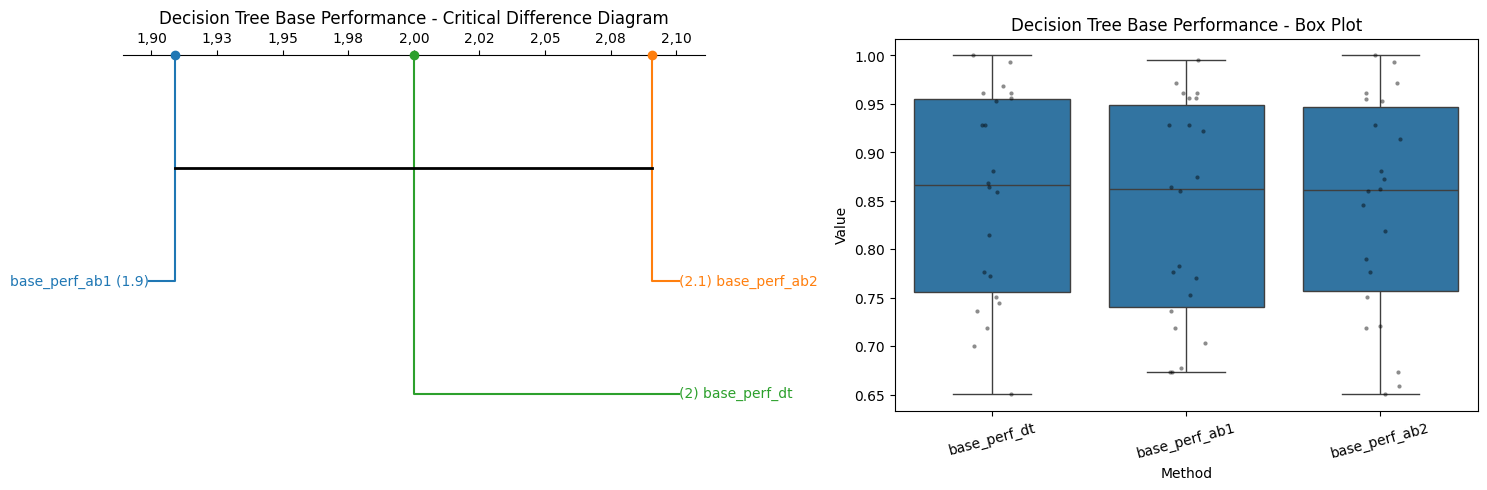

Average ranks (Decision Tree SRC) [0,00 format]:
  src_ab1: 1,55
  src_ab2: 1,45


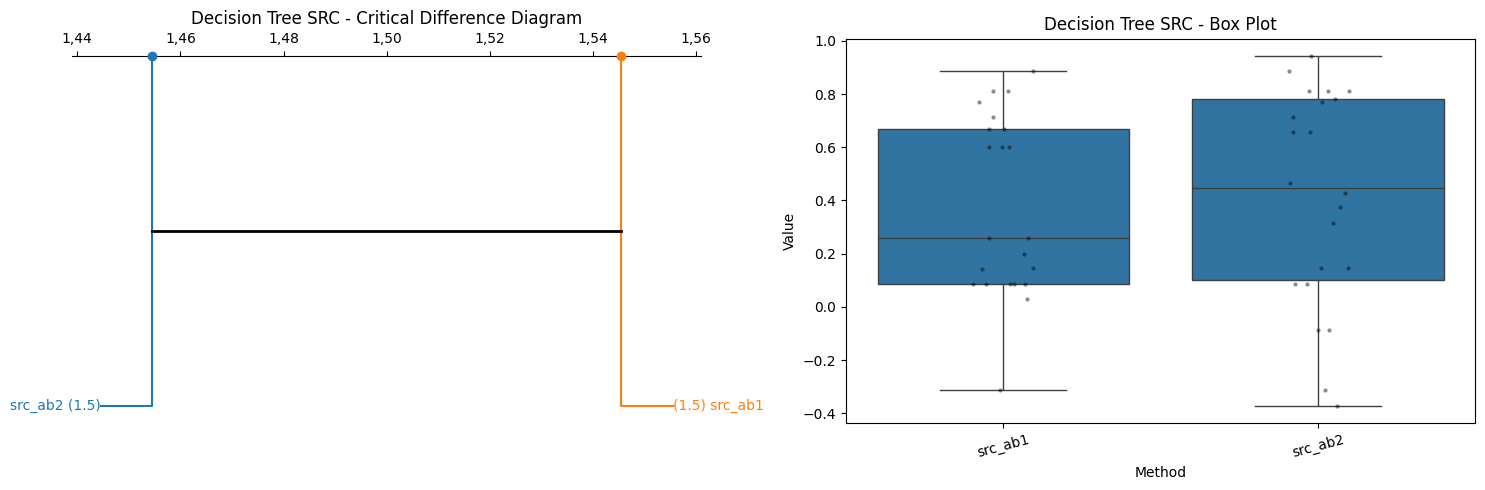

In [ ]:
import scikit_posthocs as sp
from scipy.stats import ttest_rel
from matplotlib.ticker import FuncFormatter

def plot_cd_and_box(df, id_col, title_prefix):
    method_cols = [c for c in df.columns if c != id_col]
    n_methods = len(method_cols)

    # Average ranks (higher value = better, so ascending=False)
    ranks = df[method_cols].rank(axis=1, ascending=False, method='average')
    avg_ranks = ranks.mean(axis=0)

    # Print average ranks in 0,00 format
    avg_ranks_fmt = avg_ranks.map(lambda x: f'{x:.2f}'.replace('.', ','))
    print(f'Average ranks ({title_prefix}) [0,00 format]:')
    for method in avg_ranks_fmt.index:
        print(f'  {method}: {avg_ranks_fmt[method]}')

    # Significance matrix needed by CD diagram
    if n_methods >= 3:
        p_matrix = sp.posthoc_nemenyi_friedman(df[method_cols].values)
        p_matrix.index = method_cols
        p_matrix.columns = method_cols
    else:
        m1, m2 = method_cols
        _, p = ttest_rel(df[m1], df[m2], nan_policy='omit')
        p_matrix = pd.DataFrame(
            [[1.0, p], [p, 1.0]],
            index=method_cols,
            columns=method_cols
        )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1) Critical Difference Diagram
    sp.critical_difference_diagram(avg_ranks, p_matrix, ax=axes[0])
    axes[0].set_title(f'{title_prefix} - Critical Difference Diagram')
    axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'.replace('.', ',')))

    # 2) Box Plot
    long_df = df.melt(id_vars=id_col, value_vars=method_cols, var_name='Method', value_name='Value')
    sns.boxplot(data=long_df, x='Method', y='Value', ax=axes[1])
    sns.stripplot(data=long_df, x='Method', y='Value', color='black', alpha=0.45, size=3, ax=axes[1])
    axes[1].set_title(f'{title_prefix} - Box Plot')
    axes[1].set_xlabel('Method')
    axes[1].set_ylabel('Value')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

# Base performance plots (Decision Tree)
plot_cd_and_box(
    df=base_perf_matrix,
    id_col='Dataset',
    title_prefix='Decision Tree Base Performance'
 )

# SRC plots (Decision Tree)
plot_cd_and_box(
    df=src_matrix,
    id_col='Dataset',
    title_prefix='Decision Tree SRC'
 )

Average ranks (SVM Base Performance) [0,00 format]:
  base_perf_svm_cls: 2,09
  base_perf_svm_ab1: 1,98
  base_perf_svm_ab2: 1,93


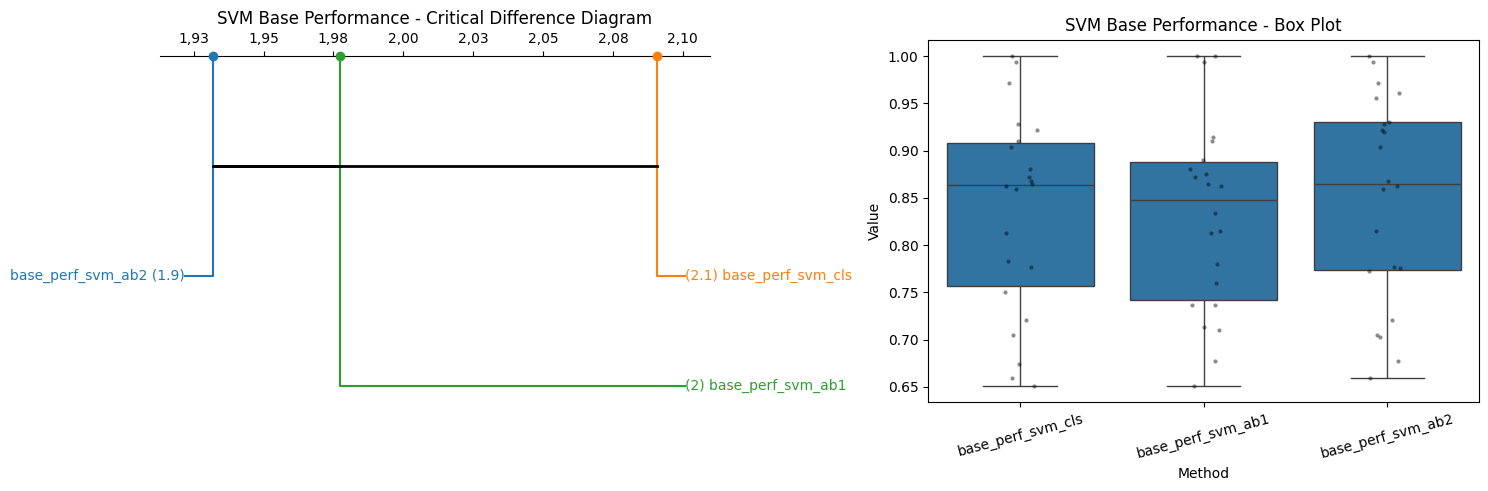

Average ranks (SVM SRC) [0,00 format]:
  src_svm_ab1: 1,68
  src_svm_ab2: 1,32


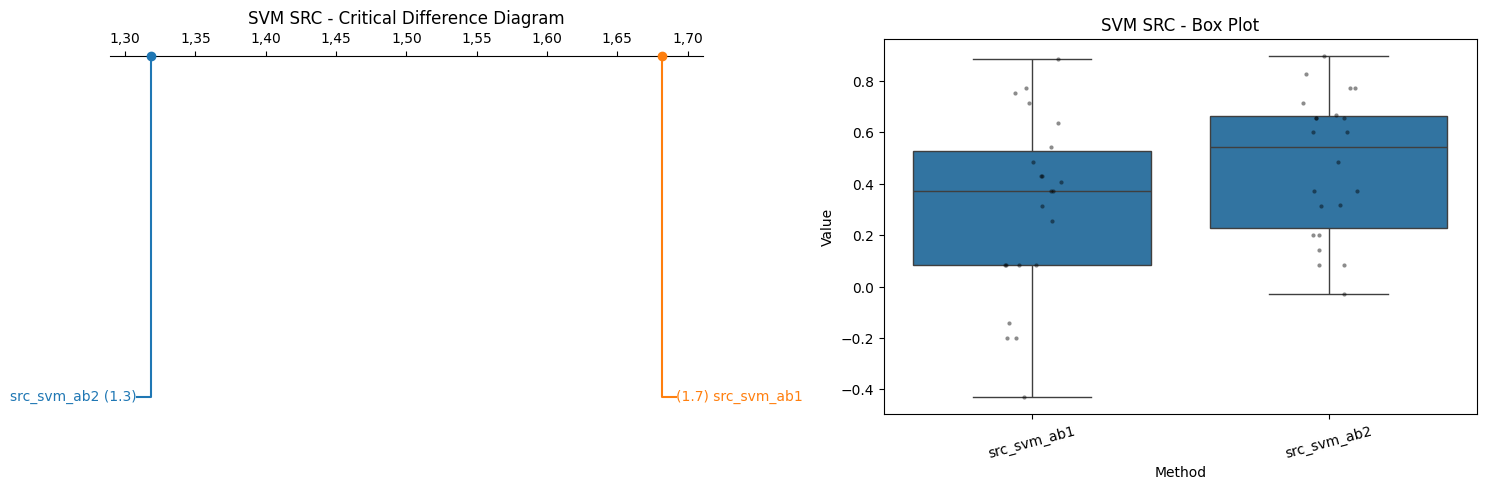

In [ ]:
# Base performance plots (SVM)
plot_cd_and_box(
    df=svm_base_perf_matrix,
    id_col='Dataset',
    title_prefix='SVM Base Performance'
 )

# SRC plots (SVM)
plot_cd_and_box(
    df=svm_src_matrix,
    id_col='Dataset',
    title_prefix='SVM SRC'
 )

# 10. Conclusões:


Este relatório apresenta uma comparação estatística de três abordagens de meta-learning aplicadas a dois modelos base — **Decision Tree** e **SVM** — em 22 datasets. As três abordagens avaliadas são:

- **Classificação** — Decision Tree Classifier que prediz diretamente o melhor algoritmo
- **Regressão (Abordagem 1 - Ab1)** — Decision Tree Regressor treinado com valores de performance
- **Regressão em Ranks (Abordagem 2 - Ab2)** — Decision Tree Regressor treinado com valores de rank

Foram usadas duas métricas de avaliação:

- **Base Performance** — acurácia do classificador recomendado por cada meta-modelo no dataset base
- **Spearman Rank Correlation (SRC)** — correlação entre o ranking predito e o ranking real dos classificadores (aplicável apenas a Ab1 e Ab2)

---

## 1. Modelo: Decision Tree

### 1.1 Normalidade

Os testes de Shapiro-Wilk mostraram que as distribuições de base performance **nao sao normais** para pelo menos uma abordagem. Por isso, testes não paramétricos foram aplicados para ambas as métricas.

### 1.2 Base Performance — Teste de Friedman

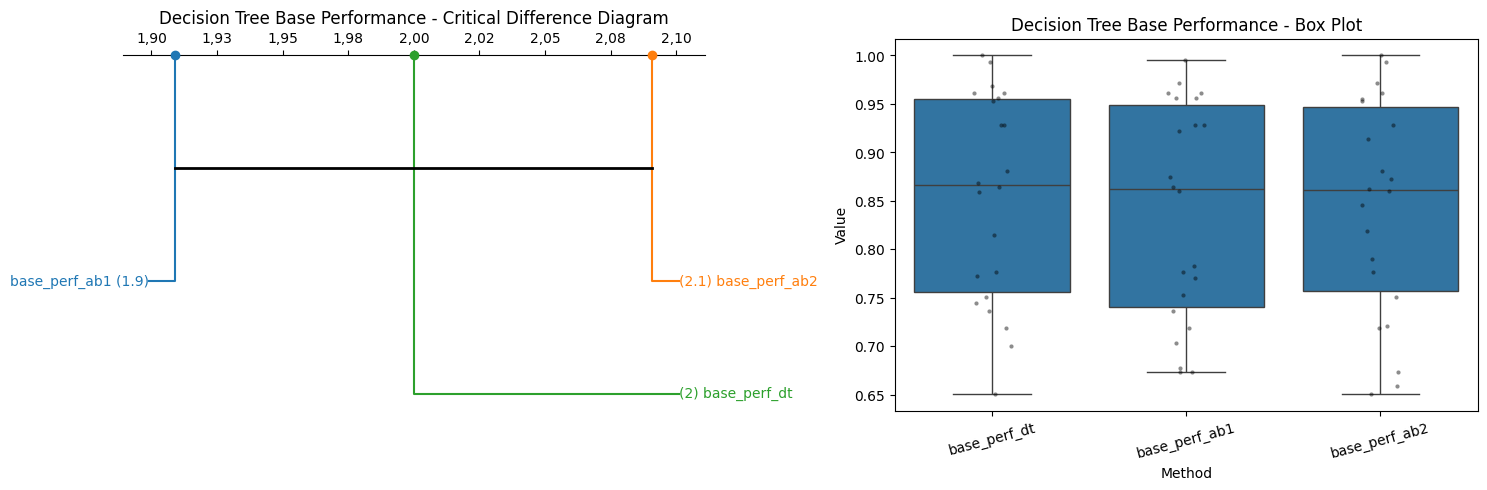

Não foi encontrada diferença estatisticamente significativa entre as três abordagens (p > 0,05).

### 1.3 SRC — Teste de Wilcoxon Signed-Rank

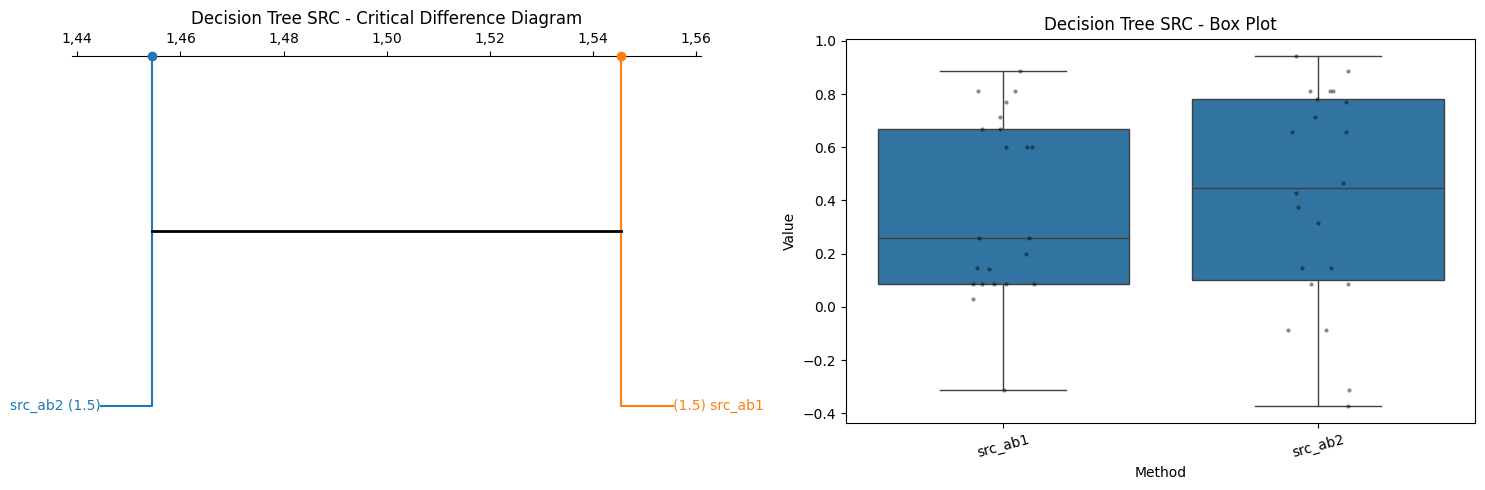

Não foi encontrada diferença estatisticamente significativa entre Ab1 e Ab2 em qualidade de ranking (p > 0,05).

### 1.4 Resumo

As três abordagens de meta-modelo são estatisticamente equivalentes para o aprendiz base Decision Tree, tanto em desempenho do classificador recomendado quanto em qualidade de ranking. A escolha entre abordagens não pode ser justificada apenas por performance; outros critérios, como tempo de treino ou interpretabilidade, devem orientar a decisão.

---

## 2. Modelo: SVM

### 2.1 Normalidade

Os testes de Shapiro-Wilk confirmaram que as distribuições de todas as abordagens são **normais** para ambas as métricas. Portanto, foram aplicados testes paramétricos.

### 2.2 Base Performance — ANOVA de Medidas Repetidas

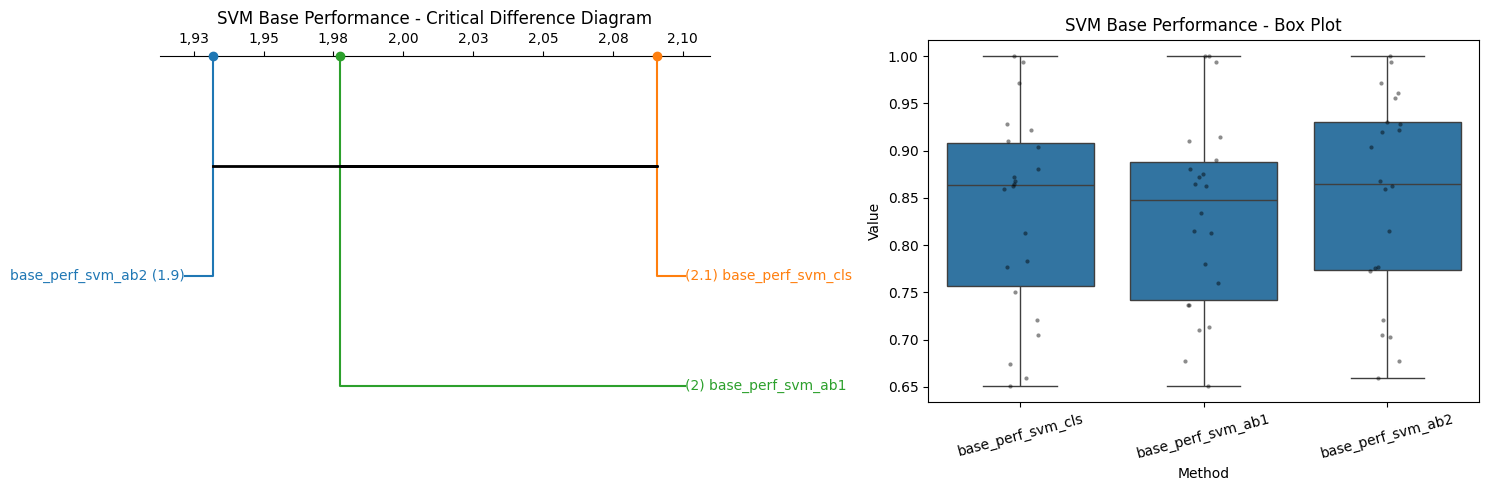

Não foi encontrada diferença estatisticamente significativa entre as três abordagens (p = 0,337, eta2 = 0,005).

### 2.3 SRC — Teste t Pareado

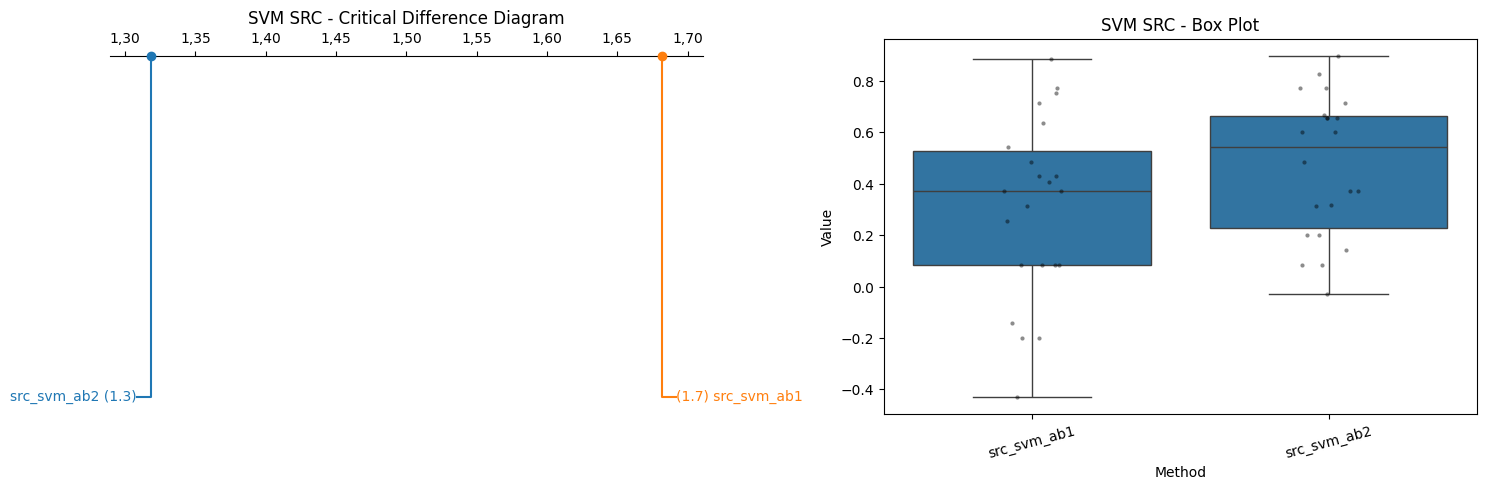

Foi encontrada diferença estatisticamente significativa entre Ab1 e Ab2 (t = -2,155, p = 0,043).

### 2.4 Resumo

Embora o desempenho base permaneça estatisticamente equivalente entre as tres abordagens, **a abordagem de ranking importa** quando o objetivo e ordenar corretamente os classificadores. A Ab2 deve ser preferida a Ab1 quando a qualidade do ranking for prioridade e o aprendiz base for SVM.

---

## 3. Conclusões Gerais

| Comparacao | Decision Tree | SVM |
|---|---|---|
| Base Performance (3 abordagens) | Sem diferença significativa | Sem diferença significativa |
| SRC (Ab1 vs Ab2) | Sem diferença significativa | **Ab2 significativamente melhor** |

O principal achado e que **a escolha do alvo da regressão (valores de performance vs valores de rank) nessa base de dados só faz diferença relevante para os modelos SVM**, em que treinar com ranks leva a uma qualidade de ranking significativamente melhor. Já para os modelos de Decision Tree, as abordagens não apresentam diferenças significativas nas duas métricas.

Esses resultados sugerem que, quando o objetivo do meta-learning e **seleção de classificador** (escolher apenas o melhor), as três abordagens são adequadas. Quando o objetivo e **ranking de classificadores** (ordenar todas as opções), a abordagem 2 é a escolha mais robusta para a base, especialmente para modelos SVM.



# Passo 11: Ampliar o metadataset

In [ ]:
import openml

# Fetch all active openml datasets and their characteristics
datasets_df = openml.datasets.list_datasets(
    output_format="dataframe",
    status="active"
)

print(f"Total active datasets on OpenML: {len(datasets_df)}")

Total active datasets on OpenML: 6387


In [ ]:
# List of loaded datasets from OpenML used in the base comparition
used_names = [
    'diabetes', 'blood-transfusion-service-center', 'monks-problems-2',
    'tic-tac-toe', 'titanic', 'pc1', 'kr-vs-kp', 'phoneme', 'wdbc',
    'semeion', 'isolet', 'cnae-9', 'ilpd-numeric', 'students_scores',
    'usps', 'ibm-employee-performance', 'mushroom', 'segment',
    'autoUniv-au1-1000', 'pizzacutter3', 'qsar', 'solar-flare'
]

# 1. Remove repeated/duplicate datasets by name
filtered_df = datasets_df.drop_duplicates(subset=['name'], keep='first')

# 2. Remove already used datasets
filtered_df = filtered_df[~filtered_df['name'].isin(used_names)]

# 3. Filter for datasets that are primarily numeric (usually 1 symbolic feature for the class target)
# Validating for appropriate classification sizes as previously configured
filtered_df = filtered_df[
    (filtered_df['NumberOfSymbolicFeatures'] <= 1) &
    (filtered_df['NumberOfNumericFeatures'] > 0) &
    (filtered_df['NumberOfInstances'] >= 50) &
    (filtered_df['NumberOfInstances'] <= 2500) &
    (filtered_df['NumberOfFeatures'] >= 2) &
    (filtered_df['NumberOfFeatures'] <= 100) &
    (filtered_df['NumberOfClasses'] >= 2) &
    (filtered_df['NumberOfClasses'] <= 10) &
    (filtered_df['NumberOfMissingValues'] == 0)
]

print(f"Total filtered datasets available: {len(filtered_df)}")

# randamly sample 200 datasets from the filtered list
sampled_df = filtered_df.sample(n=200, random_state=42).reset_index(drop=True)
print(f"Randomly sampled datasets: {len(sampled_df)}")
display(filtered_df[['did', 'name', 'NumberOfInstances', 'NumberOfFeatures', 'NumberOfClasses', 'NumberOfNumericFeatures', 'NumberOfSymbolicFeatures']].head(10))

Total filtered datasets available: 375
Randomly sampled datasets: 200


,did,name,NumberOfInstances,NumberOfFeatures,NumberOfClasses,NumberOfNumericFeatures,NumberOfSymbolicFeatures
11,11,balance-scale,625.0,5.0,3.0,4.0,1.0
14,14,mfeat-fourier,2000.0,77.0,10.0,76.0,1.0
16,16,mfeat-karhunen,2000.0,65.0,10.0,64.0,1.0
18,18,mfeat-morphological,2000.0,7.0,10.0,6.0,1.0
22,22,mfeat-zernike,2000.0,48.0,10.0,47.0,1.0
39,39,ecoli,336.0,8.0,8.0,7.0,1.0
40,40,sonar,208.0,61.0,2.0,60.0,1.0
41,41,glass,214.0,10.0,6.0,9.0,1.0
53,53,heart-statlog,270.0,14.0,2.0,13.0,1.0
54,54,vehicle,846.0,19.0,4.0,18.0,1.0


In [ ]:
import time

# Dictionary to store the downloaded datasets
downloaded_datasets = {}
failed_downloads = []

print(f"Starting download of {len(sampled_df)} datasets...")

for did in sampled_df['did']:
    name = sampled_df[sampled_df['did'] == did]['name'].values[0]
    try:
        # Download the dataset using its ID
        dataset = openml.datasets.get_dataset(did, download_data=True, download_qualities=True, download_features_meta_data=True)

        # Get the actual data dataframe
        X, y, categorical_indicator, attribute_names = dataset.get_data(
            dataset_format="dataframe", target=dataset.default_target_attribute
        )

        # Save to our dictionary using the dataset name
        downloaded_datasets[name] = {
            'did': did,
            'dataset': dataset,
            'X': X,
            'y': y,
            'categorical_indicator': categorical_indicator,
            'attribute_names': attribute_names
        }
        print(f"Successfully downloaded: {name} (ID: {did})")
    except Exception as e:
        print(f"Failed to download {name} (ID: {did}) - {e}")
        failed_downloads.append(did)

    # Optional: Short sleep to avoid being rate limited by the OpenML API
    time.sleep(0.5)

print(f"\nCompleted! Successfully downloaded {len(downloaded_datasets)} datasets.")
if failed_downloads:
    print(f"Failed to download {len(failed_downloads)} datasets: {failed_downloads}")

Starting download of 200 datasets...
Successfully downloaded: Heart_disease_prediction_20 (ID: 44149)
Successfully downloaded: jEdit_4.2_4.3 (ID: 1048)
Successfully downloaded: meta_batchincremental.arff (ID: 276)
Successfully downloaded: sylvine_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True (ID: 44678)
Successfully downloaded: MeanWhile1 (ID: 1449)
Successfully downloaded: pc4_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True (ID: 44608)
Successfully downloaded: robot-failures-lp1 (ID: 1516)
Successfully downloaded: FOREX_eurdkk-day-Close (ID: 41783)
Successfully downloaded: ada_seed_4_nrows_2000_nclasses_10_ncols_100_stratify_True (ID: 44572)
Successfully downloaded: FOREX_eursgd-day-High (ID: 41801)
Successfully downloaded: Higgs_seed_3_nrows_2000_nclasses_10_ncols_100_stratify_True (ID: 44420)
Successfully downloaded: ar4 (ID: 1061)
Successfully downloaded: vehicle_seed_3_nrows_2000_nclasses_10_ncols_100_stratify_True (ID: 44556)
Successfully downloaded: CastMetal1 (ID:

## 11.1: Avaliar performance dos classificadores nos novos datasets

In [ ]:
# Evaluate classifier performance on newly downloaded datasets
from sklearn.impute import SimpleImputer
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

new_results = []

# Reuse the same classifier set from the base experiment
classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

for dataset_name, data_info in downloaded_datasets.items():
    print(f'Processing dataset: {dataset_name}')

    # Work on copies to avoid mutating the downloaded cache
    X = data_info['X'].copy()
    y = data_info['y'].copy()

    # Drop datetime columns before imputation since imputers can't handle them
    datetime_cols = X.select_dtypes(include=['datetime', 'datetimetz']).columns
    if len(datetime_cols) > 0:
        X = X.drop(columns=datetime_cols)

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Handle categorical features
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Encode target if necessary
    if hasattr(y, 'dtype') and (y.dtype == 'object' or str(y.dtype).startswith('category')):
        le = LabelEncoder()
        y = le.fit_transform(y.astype(str))
    else:
        y = np.array(y)

    # Evaluate each classifier with stratified 5-fold CV
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(
            clf,
            X,
            y,
            cv=cv,
            scoring='accuracy',
            return_train_score=False,
            error_score='raise'
        )

        fold_accs = cv_results['test_score']

        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }

        new_results.append(result_row)
        print('Done')

# Create DataFrame with classifier performances for the new datasets
new_performances_df = pd.DataFrame(new_results)
print(f"\nFinished. Total rows in new_performances_df: {len(new_performances_df)}")
display(new_performances_df.head())

Processing dataset: Heart_disease_prediction_20
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: jEdit_4.2_4.3
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: meta_batchincremental.arff
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: sylvine_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: MeanWhile1
  Evaluating DecisionTree... Done


,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,Heart_disease_prediction_20,DecisionTree,0.783333,0.677966,0.711864,0.796610,0.711864,0.736328,0.045709,0.009854,0.006651
1,Heart_disease_prediction_20,SVM,0.600000,0.661017,0.694915,0.661017,0.644068,0.652203,0.030890,0.013853,0.010165
2,Heart_disease_prediction_20,KNN,0.633333,0.644068,0.661017,0.728814,0.677966,0.669040,0.033513,0.007905,0.012324
3,Heart_disease_prediction_20,LogisticRegression,0.850000,0.915254,0.796610,0.830508,0.813559,0.841186,0.041056,0.880543,0.007656
4,Heart_disease_prediction_20,Perceptron,0.533333,0.576271,0.779661,0.627119,0.610169,0.625311,0.083572,0.008221,0.006352


In [ ]:
new_performances_df.to_csv('new_datasets_classifier_performances.csv', index=False)

## 11.2: Extraindo Metafeatures dos novos datasets

In [ ]:
# Extract meta-features from newly downloaded datasets
new_meta_features = []

for dataset_name, data_info in downloaded_datasets.items():
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    # Get data and target
    X = data_info['X'].copy()
    y = data_info['y'].copy()

    # Handle categorical features
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Drop datetime columns before imputation since imputers can't handle them
    datetime_cols = X.select_dtypes(include=['datetime', 'datetimetz']).columns
    if len(datetime_cols) > 0:
        X = X.drop(columns=datetime_cols)

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Encode target if necessary
    if y.dtype == 'object' or hasattr(y, 'cat'):
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)

    # Extract meta-features
    try:
        # Re-using the groups from the base cell
        mfe = MFE(groups=["general", "statistical", "info-theory", "clustering"], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()

        new_meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame for the new datasets
if new_meta_features:
    new_meta_features_df = pd.concat(new_meta_features, ignore_index=False)
    print(f"\nSuccessfully extracted meta-features for {len(new_meta_features_df)} new datasets.")
    display(new_meta_features_df.head())
else:
    new_meta_features_df = pd.DataFrame()
    print("\nNo meta-features extracted.")

Extracting meta-features from Heart_disease_prediction_20... Done
Extracting meta-features from jEdit_4.2_4.3... Done
Extracting meta-features from meta_batchincremental.arff... Done
Extracting meta-features from sylvine_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True... Done
Extracting meta-features from MeanWhile1... Done
Extracting meta-features from pc4_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True... Done
Extracting meta-features from robot-failures-lp1... Done
Extracting meta-features from FOREX_eurdkk-day-Close... Done
Extracting meta-features from ada_seed_4_nrows_2000_nclasses_10_ncols_100_stratify_True... Done
Extracting meta-features from FOREX_eursgd-day-High... Done
Extracting meta-features from Higgs_seed_3_nrows_2000_nclasses_10_ncols_100_stratify_True... Done
Extracting meta-features from ar4... Done
Extracting meta-features from vehicle_seed_3_nrows_2000_nclasses_10_ncols_100_stratify_True... Done
Extracting meta-features from CastMetal1... Done
Extractin

,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,cov.mean,...,sd.mean,sd_ratio,sil,skewness.mean,sparsity.mean,t_mean.mean,var.mean,vdb,vdu,w_lambda
Heart_disease_prediction_20,0.032033,1.653602,0.043919,0.731583,0.0,10.469399,0.083105,0.996012,0.156150,5.961880,...,8.369718,1.056084,0.043977,0.423355,0.234873,45.314434,2.803260e+02,4.526919,4.924674e-07,0.464786
jEdit_4.2_4.3,0.095097,2.384059,0.021680,0.340004,0.0,10.371772,0.010961,0.991927,0.307005,2039.221092,...,105.351900,1.259463,0.004572,4.366750,0.031330,30.084641,3.788357e+04,3.795045,1.244311e-08,0.884397
meta_batchincremental.arff,0.126934,1.708623,0.837838,0.933563,0.0,0.166858,0.047793,1.310030,0.255610,39226.499394,...,309.369701,NaN,-0.668205,1.676878,0.045456,16.589137,2.657210e+06,2.291651,6.034366e-08,0.001764
sylvine_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True,0.010825,3.579477,0.010000,0.731647,0.0,14.862364,0.004831,1.000000,0.055908,7463.817566,...,418.751719,1.047768,0.011655,0.114419,0.004594,802.608833,5.290606e+05,11.056917,3.765217e-08,0.464692
MeanWhile1,0.144516,2.258945,0.146245,0.521175,0.0,6.181017,0.015491,0.489941,0.433949,56705.670002,...,576.168564,NaN,0.290652,2.101923,0.042395,169.079081,1.004719e+07,2.728273,2.670596e-08,0.728376


In [ ]:
new_meta_features_df.to_csv('new_datasets_meta_features.csv', index=True)

## 11.3: Combinar Meta-features e Performances

In [ ]:
new_performances_df = pd.read_csv('new_datasets_classifier_performances.csv')
new_meta_features_df = pd.read_csv('new_datasets_meta_features.csv', index_col=0)

# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
new_performances_df2 = new_performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
new_performances_df2.columns.name = None
new_performances_df2 = new_performances_df2.reset_index()

# Merge performances_df2 with meta_features_df based on dataset name
new_meta_dataset = new_performances_df2.merge(
    right=new_meta_features_df,
    left_on='Dataset',
    right_index=True,
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = new_meta_features_df.columns.tolist()
classifier_cols = new_performances_df2.columns.drop('Dataset').tolist()
new_meta_dataset = new_meta_dataset[['Dataset'] + meta_cols + classifier_cols]

# Get the classifier columns (last 6 columns typically)
# Find the classifier with the best (maximum) accuracy for each dataset
new_meta_dataset['Best'] = new_meta_dataset[classifier_cols].idxmax(axis=1)

display(new_meta_dataset)

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,CPMP-2015-runtime-classification,0.117416,2.247287,0.041746,0.429835,0.0,40.132779,0.087480,1.880060,0.321950,...,7.883202,2.246477e-07,0.481898,0.430710,0.497125,0.563630,0.563594,0.493513,0.521905,LogisticRegression
1,CastMetal1,0.186128,2.430961,0.113150,0.496736,0.0,2.595650,0.010172,0.553145,0.529708,...,3.512478,1.146111e-09,0.753253,0.807459,0.859441,0.856597,0.663497,0.862378,0.871608,SVM
2,Credit_Approval_Classification,0.093760,1.536256,0.020000,0.424643,0.0,24.482504,0.057186,0.881291,0.073129,...,4.661415,1.296671e-09,0.819679,0.679000,0.625000,0.680000,0.692000,0.543000,0.700000,SVM
3,Creditability-German-Credit-Data,0.016089,1.571426,0.020000,0.487218,0.0,24.483002,0.008726,0.881291,0.080843,...,4.661371,1.122950e-09,0.762618,0.685000,0.648000,0.749000,0.700000,0.611000,0.711000,LogisticRegression
4,Estimation_of_Obesity_Levels,0.039499,1.840552,0.007579,0.491426,0.0,1464.352466,0.126084,2.802569,0.105500,...,2.232225,1.350698e-07,0.013152,0.928472,0.812875,0.575537,0.766443,0.384183,0.861683,DecisionTree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,wine_seed_2_nrows_2000_nclasses_10_ncols_100_s...,0.027096,3.569714,0.005500,0.540857,0.0,9.934201,0.006521,1.000000,0.239043,...,11.529257,1.358993e-09,0.707474,0.741500,0.645000,0.731500,0.725000,0.538000,0.612000,DecisionTree
196,wine_seed_4_nrows_2000_nclasses_10_ncols_100_s...,0.026633,3.570909,0.005500,0.544145,0.0,14.544613,0.006701,1.000000,0.244473,...,9.636736,1.713571e-09,0.703907,0.742000,0.658000,0.739500,0.730000,0.540000,0.624000,DecisionTree
197,yeast_seed_0_nrows_2000_nclasses_10_ncols_100_...,0.008721,2.419835,0.005391,0.447947,0.0,68.356867,0.131741,2.490418,0.089273,...,2.928163,7.062503e-08,0.078519,0.505419,0.558643,0.551231,0.606507,0.448724,0.597727,MLP
198,yeast_seed_1_nrows_2000_nclasses_10_ncols_100_...,0.008721,2.419835,0.005391,0.447947,0.0,68.356867,0.131741,2.490418,0.089273,...,2.928163,7.062503e-08,0.078519,0.505419,0.558643,0.551231,0.606507,0.448724,0.597727,MLP


# 12: treinando e avaliando os meta-modelos com os novos datasets

In [ ]:
# weighted rank correlation (RW) implementation available in https://github.com/amorimlb/Meta-aprendizagem-2026.1-code/blob/main/rank_correlation_measures.py

def weightedrankcorrelation(rankA, rankB):
    numerator = 0
    n = len(rankA)
    denominator = n**4 + n**3 - n**2 - n
    if denominator == 0:
        return np.nan
    for r, q in zip(rankA, rankB):
        numerator += ((r - q) ** 2)*((n - r + 1)+(n - q + 1))
    rw = 1 - 6*numerator / denominator
    return rw

## 12.1: Abordagem 1 regressao na performance

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, f1_score, ndcg_score
from time import time
import pandas as pd
import numpy as np

# Create a dictionary to store the results
new_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': [],
    'SRC': [],
    'RW': [],
    'NDCG': [],
    'LA@3': [],
    'Predicted Order': [],
    'True Scores': []
}

loo = LeaveOneOut()
new_y_true_best = []
new_y_pred_best = []
new_rank_ab1_train_time = 0.0
new_rank_ab1_test_time = 0.0

from sklearn.impute import SimpleImputer

# Global imputation of infinite and missing values to prevent train errors
X_all = new_meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
X_all = X_all.replace([np.inf, -np.inf], np.nan)

#drop columns that are all NaN (Eu acho que apenas a coluna 'num_to_cat' ja que tinha filtrado por datasets com apenas dados numericos entao fica um divisao por zero...)
X_all = X_all.dropna(axis=1, how='all')
imputer = SimpleImputer(strategy='mean')
X_all = pd.DataFrame(imputer.fit_transform(X_all), columns=X_all.columns, index=X_all.index)
y_all = new_meta_dataset[classifier_cols]

for train_index, test_index in loo.split(X_all):
    X_train, X_test = X_all.iloc[train_index], X_all.iloc[test_index]
    y_train, y_test = y_all.iloc[train_index], y_all.iloc[test_index]

    # Train regressor to predict classifier performances
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train)
    new_rank_ab1_train_time += time() - t0

    # Predicted performances for each classifier on the test dataset
    t0 = time()
    pred_scores = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_scores.idxmax()
    new_rank_ab1_test_time += time() - t0

    # True performances for each classifier on the test dataset
    true_scores = y_test.iloc[0]
    true_best_clf = true_scores.idxmax()

    # Convert scores to ranks (1 is the best)
    true_ranks = true_scores.rank(ascending=False)
    pred_ranks = pred_scores.rank(ascending=False)

    # Spearman rank correlation (SRC) between predicted and true classifier score vectors
    fold_src = pred_ranks.corr(true_ranks, method='spearman')

    # weighted rank correlation (RW)
    fold_rw = weightedrankcorrelation(true_ranks, pred_ranks)

    # NDCG
    fold_ndcg = ndcg_score([true_ranks.values], [pred_ranks.values])

    # LA@3: Loose accuracy (1 if the true best classifier is among the top 3 predicted ones, else 0)
    top3_clfs = pred_scores.nlargest(3).index
    fold_la3 = 1 if true_best_clf in top3_clfs else 0

    new_y_true_best.append(true_best_clf)
    new_y_pred_best.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = new_meta_dataset['Dataset'].iloc[test_index[0]]
    new_summary_of_predictions['Dataset'].append(dataset_name)
    new_summary_of_predictions['Best clf (true)'].append(true_best_clf)
    new_summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    new_summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    # performance obtained by selecting the predicted best classifier
    new_summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])
    new_summary_of_predictions['SRC'].append(fold_src)
    new_summary_of_predictions['RW'].append(fold_rw)
    new_summary_of_predictions['NDCG'].append(fold_ndcg)
    new_summary_of_predictions['LA@3'].append(fold_la3)
    new_summary_of_predictions['Predicted Order'].append(pred_scores.sort_values(ascending=False).index.tolist())
    new_summary_of_predictions['True Scores'].append(true_scores.to_dict())

# Create a DataFrame from the summary of predictions
new_rank_ab1_summary_df = pd.DataFrame(new_summary_of_predictions)

# Calculate and store meta-model metrics over predicted best-classifier labels
new_rank_ab1_base_perf = new_rank_ab1_summary_df['Perf of best clf (pred)'].mean()
new_rank_ab1_meta_model_accuracy = accuracy_score(new_y_true_best, new_y_pred_best)
new_rank_ab1_meta_model_f1 = f1_score(new_y_true_best, new_y_pred_best, average='weighted')
new_rank_ab1_src = new_rank_ab1_summary_df['SRC'].mean()
new_rank_ab1_rw = new_rank_ab1_summary_df['RW'].mean()
new_rank_ab1_ndcg = new_rank_ab1_summary_df['NDCG'].mean()
new_rank_ab1_la3 = new_rank_ab1_summary_df['LA@3'].mean()

print(f'Meta-model Accuracy: {new_rank_ab1_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {new_rank_ab1_meta_model_f1:.2f}')
print(f'Training time (s): {new_rank_ab1_train_time:.4f}')
print(f'Testing time (s): {new_rank_ab1_test_time:.4f}')
print(f'Base perf: {new_rank_ab1_base_perf:.4f}')
print(f'SRC: {new_rank_ab1_src:.4f}')
print(f'RW: {new_rank_ab1_rw:.4f}')
print(f'NDCG: {new_rank_ab1_ndcg:.4f}')
print(f'LA@3: {new_rank_ab1_la3:.4f}')

Meta-model Accuracy: 0.62
Meta-model F1-score: 0.63
Training time (s): 1.0829
Testing time (s): 0.1981
Base perf: 0.7400
SRC: 0.6471
RW: 0.6507
NDCG: 0.9474
LA@3: 0.8650


In [ ]:
# Create a dictionary to store the results
new_summary_of_predictions2 = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': [],
    'SRC': [],
    'RW': [],
    'NDCG': [],
    'LA@3': [],
    'Predicted Order': [],
    'True Scores': []
}

from sklearn.metrics import ndcg_score

loo = LeaveOneOut()
new_y_true_best2 = []
new_y_pred_best2 = []
new_rank_ab2_train_time = 0.0
new_rank_ab2_test_time = 0.0
new_rank_ab2_src_values = []

# Global imputation of infinite and missing values to prevent train errors
X_all = new_meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.dropna(axis=1, how='all')
imputer = SimpleImputer(strategy='mean')
X_all = pd.DataFrame(imputer.fit_transform(X_all), columns=X_all.columns, index=X_all.index)

# Raw classifier performances (for reporting obtained performance)
y_raw = new_meta_dataset[classifier_cols]

# Convert classifier performances to ranks per dataset (1 = best classifier)
y_rank = y_raw.rank(axis=1, ascending=False, method='average')

for train_index, test_index in loo.split(X_all):
    X_train, X_test = X_all.iloc[train_index], X_all.iloc[test_index]
    y_train_rank = y_rank.iloc[train_index]
    y_test_rank = y_rank.iloc[test_index]
    y_test_raw = y_raw.iloc[test_index]

    # Train regressor to predict classifier ranks
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train_rank)
    new_rank_ab2_train_time += time() - t0

    # Predicted ranks for each classifier on the test dataset
    t0 = time()
    pred_ranks = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_ranks.idxmin()
    new_rank_ab2_test_time += time() - t0

    # True ranks for each classifier on the test dataset
    true_ranks = y_test_rank.iloc[0]
    true_best_clf = true_ranks.idxmin()
    true_scores = y_test_raw.iloc[0]

    # Spearman rank correlation (SRC) between predicted and true rank vectors
    fold_src = pred_ranks.corr(true_ranks, method='spearman')

    # weighted rank correlation (RW)
    fold_rw = weightedrankcorrelation(true_ranks, pred_ranks)

    # NDCG
    fold_ndcg = ndcg_score([true_ranks.values], [pred_ranks.values])

    # LA@3: Loose accuracy (1 if the true best classifier is among the top 3 predicted ones, else 0)
    top3_clfs = pred_ranks.nsmallest(3).index
    fold_la3 = 1 if true_best_clf in top3_clfs else 0

    new_y_true_best2.append(true_best_clf)
    new_y_pred_best2.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = new_meta_dataset['Dataset'].iloc[test_index[0]]
    new_summary_of_predictions2['Dataset'].append(dataset_name)
    new_summary_of_predictions2['Best clf (true)'].append(true_best_clf)
    new_summary_of_predictions2['Perf of best clf (true)'].append(true_scores[true_best_clf])
    new_summary_of_predictions2['Best clf (pred)'].append(pred_best_clf)
    new_summary_of_predictions2['Perf of best clf (pred)'].append(true_scores[pred_best_clf])
    new_summary_of_predictions2['SRC'].append(fold_src)
    new_summary_of_predictions2['RW'].append(fold_rw)
    new_summary_of_predictions2['NDCG'].append(fold_ndcg)
    new_summary_of_predictions2['LA@3'].append(fold_la3)
    new_summary_of_predictions2['Predicted Order'].append(pred_ranks.sort_values(ascending=True).index.tolist())
    new_summary_of_predictions2['True Scores'].append(true_scores.to_dict())

# Create a DataFrame from the summary of predictions
new_rank_ab2_summary_df = pd.DataFrame(new_summary_of_predictions2)

# Calculate and store meta-model metrics over predicted best-classifier labels
new_rank_ab2_base_perf = new_rank_ab2_summary_df['Perf of best clf (pred)'].mean()
new_rank_ab2_meta_model_accuracy = accuracy_score(new_y_true_best2, new_y_pred_best2)
new_rank_ab2_meta_model_f1 = f1_score(new_y_true_best2, new_y_pred_best2, average='weighted')
new_rank_ab2_src = new_rank_ab2_summary_df['SRC'].mean()
new_rank_ab2_rw = new_rank_ab2_summary_df['RW'].mean()
new_rank_ab2_ndcg = new_rank_ab2_summary_df['NDCG'].mean()
new_rank_ab2_la3 = new_rank_ab2_summary_df['LA@3'].mean()

print(f'Meta-model Accuracy (rank target): {new_rank_ab2_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score (rank target): {new_rank_ab2_meta_model_f1:.2f}')
print(f'Training time (s): {new_rank_ab2_train_time:.4f}')
print(f'Testing time (s): {new_rank_ab2_test_time:.4f}')
print(f'Base perf: {new_rank_ab2_base_perf:.4f}')
print(f'SRC: {new_rank_ab2_src:.4f}')
print(f'RW: {new_rank_ab2_rw:.4f}')
print(f'NDCG: {new_rank_ab2_ndcg:.4f}')
print(f'LA@3: {new_rank_ab2_la3:.4f}')

Meta-model Accuracy (rank target): 0.55
Meta-model F1-score (rank target): 0.55
Training time (s): 1.1051
Testing time (s): 0.1977
Base perf: 0.7350
SRC: 0.6240
RW: 0.6299
NDCG: 0.9432
LA@3: 0.8550


In [ ]:
# Average Rank baseline on the new datasets
new_ar_summary = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': [],
    'SRC': [],
    'RW': [],
    'NDCG': [],
    'LA@3': [],
    'Predicted Order': [],
    'True Scores': []
}

new_y_true_best_ar = []
new_y_pred_best_ar = []
new_ar_train_time = 0.0
new_ar_test_time = 0.0
new_ar_src_values = []

from sklearn.metrics import ndcg_score

# Raw classifier performances and their ranks
y_raw_new = new_meta_dataset[classifier_cols]
y_rank_new = y_raw_new.rank(axis=1, ascending=False, method='average')

for train_index, test_index in loo.split(new_meta_dataset):
    y_train_rank = y_rank_new.iloc[train_index]
    y_test_raw = y_raw_new.iloc[test_index]
    y_test_rank = y_rank_new.iloc[test_index]

    # "Training": calculate the average rank of each classifier on the training datasets
    t0 = time()
    avg_ranks = y_train_rank.mean(axis=0)
    new_ar_train_time += time() - t0

    # "Testing": predict the classifier with the best (lowest) average rank
    t0 = time()
    pred_best_clf = avg_ranks.idxmin()
    new_ar_test_time += time() - t0

    # True best classifier
    true_scores = y_test_raw.iloc[0]
    true_best_clf = true_scores.idxmax()
    true_ranks = y_test_rank.iloc[0]

    # Spearman rank correlation (SRC)
    fold_src = avg_ranks.corr(true_ranks, method='spearman')

    # weighted rank correlation (RW)
    fold_rw = weightedrankcorrelation(true_ranks, avg_ranks)

    # NDCG
    fold_ndcg = ndcg_score([true_ranks.values], [avg_ranks.values])

    # LA@3: Loose accuracy (1 if the true best classifier is among the top 3 predicted ones, else 0)
    top3_clfs = avg_ranks.nsmallest(3).index
    fold_la3 = 1 if true_best_clf in top3_clfs else 0

    new_y_true_best_ar.append(true_best_clf)
    new_y_pred_best_ar.append(pred_best_clf)

    dataset_name = new_meta_dataset['Dataset'].iloc[test_index[0]]
    new_ar_summary['Dataset'].append(dataset_name)
    new_ar_summary['Best clf (true)'].append(true_best_clf)
    new_ar_summary['Perf of best clf (true)'].append(true_scores[true_best_clf])
    new_ar_summary['Best clf (pred)'].append(pred_best_clf)
    new_ar_summary['Perf of best clf (pred)'].append(true_scores[pred_best_clf])
    new_ar_summary['SRC'].append(fold_src)
    new_ar_summary['RW'].append(fold_rw)
    new_ar_summary['NDCG'].append(fold_ndcg)
    new_ar_summary['LA@3'].append(fold_la3)
    new_ar_summary['Predicted Order'].append(avg_ranks.sort_values(ascending=True).index.tolist())
    new_ar_summary['True Scores'].append(true_scores.to_dict())

new_ar_summary_df = pd.DataFrame(new_ar_summary)

# Calculate metrics
new_ar_base_perf = new_ar_summary_df['Perf of best clf (pred)'].mean()
new_ar_accuracy = accuracy_score(new_y_true_best_ar, new_y_pred_best_ar)
new_ar_f1 = f1_score(new_y_true_best_ar, new_y_pred_best_ar, average='weighted')
new_ar_src = new_ar_summary_df['SRC'].mean()
new_ar_rw = new_ar_summary_df['RW'].mean()
new_ar_ndcg = new_ar_summary_df['NDCG'].mean()
new_ar_la3 = new_ar_summary_df['LA@3'].mean()

print(f'Average Rank Accuracy: {new_ar_accuracy:.2f}')
print(f'Average Rank F1-score: {new_ar_f1:.2f}')
print(f'Training time (s): {new_ar_train_time:.4f}')
print(f'Testing time (s): {new_ar_test_time:.4f}')
print(f'Base perf: {new_ar_base_perf:.4f}')
print(f'SRC: {new_ar_src:.4f}')
print(f'NDCG: {new_ar_ndcg:.4f}')
print(f'LA@3: {new_ar_la3:.4f}')

Average Rank Accuracy: 0.44
Average Rank F1-score: 0.27
Training time (s): 0.0229
Testing time (s): 0.0061
Base perf: 0.7258
SRC: 0.4430
NDCG: 0.9322
LA@3: 0.7550


# 13: Gráficos e Comparações

In [ ]:
# Create a comparison table for the 3 approaches on the new datasets
comparison_data = {
    'Metric': [
        'Accuracy',
        'F1-score',
        'Training time (s)',
        'Testing time (s)',
        'Base perf',
        'SRC',
        'RW',
        'NDCG',
        'LA@3'
    ],
    'Approach 1 (Perf target)': [
        new_rank_ab1_meta_model_accuracy,
        new_rank_ab1_meta_model_f1,
        new_rank_ab1_train_time,
        new_rank_ab1_test_time,
        new_rank_ab1_base_perf,
        new_rank_ab1_src,
        new_rank_ab1_rw,
        new_rank_ab1_ndcg,
        new_rank_ab1_la3
    ],
    'Approach 2 (Rank target)': [
        new_rank_ab2_meta_model_accuracy,
        new_rank_ab2_meta_model_f1,
        new_rank_ab2_train_time,
        new_rank_ab2_test_time,
        new_rank_ab2_base_perf,
        new_rank_ab2_src,
        new_rank_ab2_rw,
        new_rank_ab2_ndcg,
        new_rank_ab2_la3
    ],
    'Average Rank (Baseline)': [
        new_ar_accuracy,
        new_ar_f1,
        new_ar_train_time,
        new_ar_test_time,
        new_ar_base_perf,
        new_ar_src,
        new_ar_rw,
        new_ar_ndcg,
        new_ar_la3
    ]
}

comparison_df = pd.DataFrame(comparison_data).set_index('Metric').T
display(comparison_df.round(4))

Metric,Accuracy,F1-score,Training time (s),Testing time (s),Base perf,SRC,RW,NDCG,LA@3
Approach 1 (Perf target),0.625,0.6278,1.0829,0.1981,0.7400,0.6471,0.6507,0.9474,0.865
Approach 2 (Rank target),0.545,0.5482,1.1051,0.1977,0.7350,0.6240,0.6299,0.9432,0.855
Average Rank (Baseline),0.440,0.2689,0.0229,0.0061,0.7258,0.4430,0.6173,0.9322,0.755


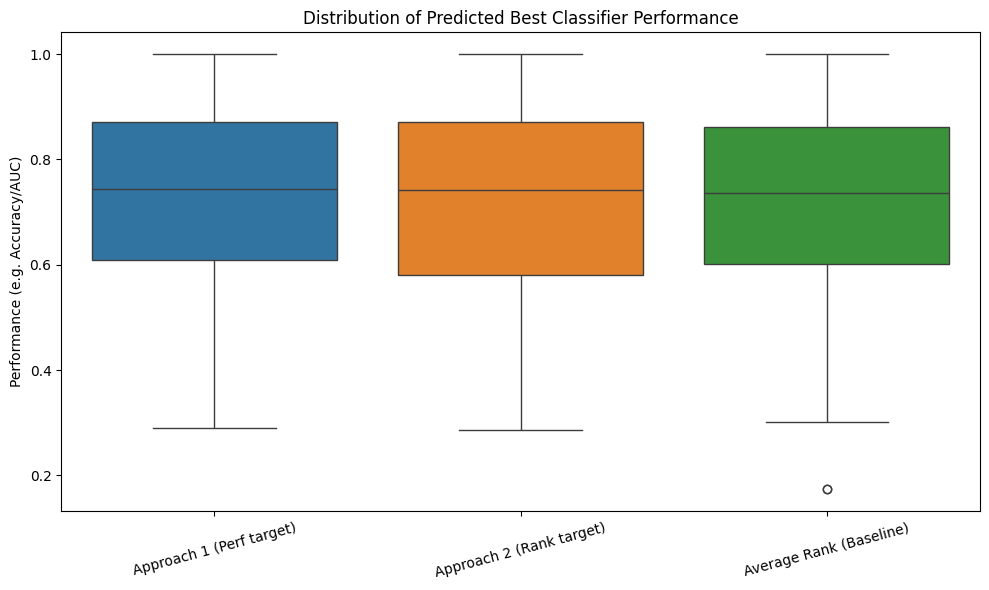

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the predicted best classifier performance for all three approaches
perf_data = pd.DataFrame({
    'Approach 1 (Perf target)': new_rank_ab1_summary_df['Perf of best clf (pred)'],
    'Approach 2 (Rank target)': new_rank_ab2_summary_df['Perf of best clf (pred)'],
    'Average Rank (Baseline)': new_ar_summary_df['Perf of best clf (pred)']
})

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=perf_data)
plt.title('Distribution of Predicted Best Classifier Performance')
plt.ylabel('Performance (e.g. Accuracy/AUC)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

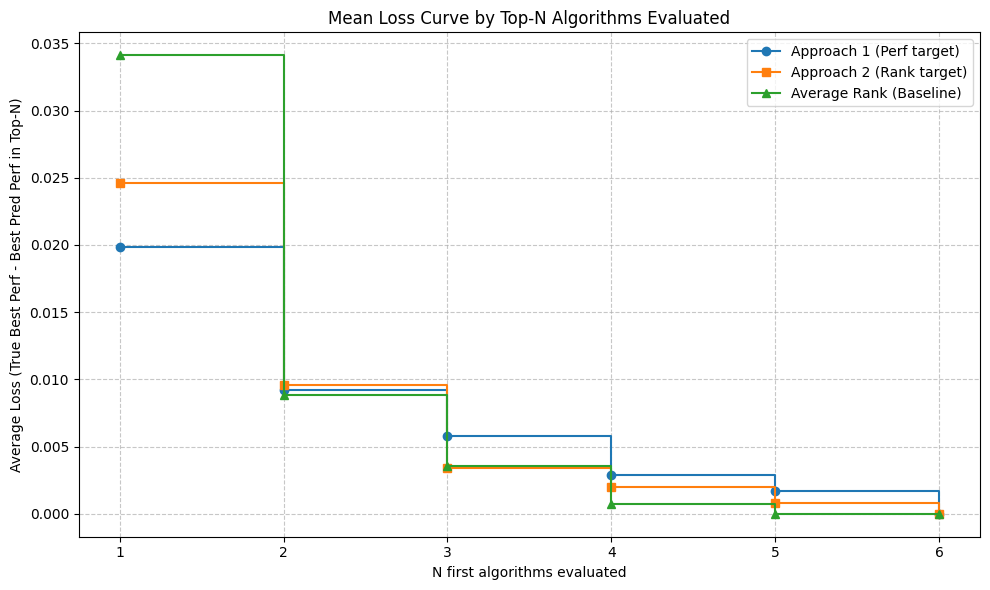

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_loss_curve_from_summary(summary_df, classifier_cols):
    loss_curves = []
    n_classifiers = len(classifier_cols)
    x_values = np.arange(1, n_classifiers + 1)

    for _, row in summary_df.iterrows():
        order = row['Predicted Order']
        true_scores = pd.Series(row['True Scores'])
        true_best_perf = true_scores.max()

        fold_loss = []
        for n in x_values:
            # Best true performance within the top-n predicted algorithms
            best_in_top_n = true_scores[order[:n]].max()
            fold_loss.append(true_best_perf - best_in_top_n)
        loss_curves.append(fold_loss)

    return np.mean(loss_curves, axis=0), x_values

# Retrieve data from summaries
avg_loss_curve_ab1, x_values = compute_loss_curve_from_summary(new_rank_ab1_summary_df, classifier_cols)
avg_loss_curve_ab2, _ = compute_loss_curve_from_summary(new_rank_ab2_summary_df, classifier_cols)
avg_loss_curve_ar, _ = compute_loss_curve_from_summary(new_ar_summary_df, classifier_cols)

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.step(x_values, avg_loss_curve_ab1, marker='o', where='post', label='Approach 1 (Perf target)')
plt.step(x_values, avg_loss_curve_ab2, marker='s', where='post', label='Approach 2 (Rank target)')
plt.step(x_values, avg_loss_curve_ar, marker='^', where='post', label='Average Rank (Baseline)')

plt.title('Mean Loss Curve by Top-N Algorithms Evaluated')
plt.xlabel('N first algorithms evaluated')
plt.ylabel('Average Loss (True Best Perf - Best Pred Perf in Top-N)')
plt.xticks(x_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro
import pandas as pd

metrics_to_test = ['Perf of best clf (pred)', 'SRC', 'RW', 'NDCG', 'LA@3']

summaries = {
    'Approach 1 (Perf target)': new_rank_ab1_summary_df,
    'Approach 2 (Rank target)': new_rank_ab2_summary_df,
    'Average Rank (Baseline)': new_ar_summary_df
}

normality_results = []

for approach_name, df in summaries.items():
    for metric in metrics_to_test:
        # Drop NaNs to prevent test failure, and cast to float
        data = df[metric].dropna().astype(float)

        # Shapiro-Wilk requires at least 3 samples
        if len(data) >= 3:
            stat, p_value = shapiro(data)
            is_normal = 'Yes' if p_value > 0.05 else 'No'

            normality_results.append({
                'Approach': approach_name,
                'Metric': metric,
                'W-Statistic': round(stat, 4),
                'p-value': f"{p_value:.4e}",
                'Normal (p>0.05)?': is_normal
            })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

,Approach,Metric,W-Statistic,p-value,Normal (p>0.05)?
0,Approach 1 (Perf target),Perf of best clf (pred),0.9660,9.2295e-05,No
1,Approach 1 (Perf target),SRC,0.8509,4.7671e-13,No
2,Approach 1 (Perf target),RW,0.8402,1.4778e-13,No
3,Approach 1 (Perf target),NDCG,0.8251,3.0842e-14,No
4,Approach 1 (Perf target),LA@3,0.4035,2.6436e-25,No
5,Approach 2 (Rank target),Perf of best clf (pred),0.9610,2.5729e-05,No
6,Approach 2 (Rank target),SRC,0.8115,8.1313e-15,No
7,Approach 2 (Rank target),RW,0.8043,4.1281e-15,No
8,Approach 2 (Rank target),NDCG,0.7956,1.8674e-15,No
9,Approach 2 (Rank target),LA@3,0.4188,4.9266e-25,No


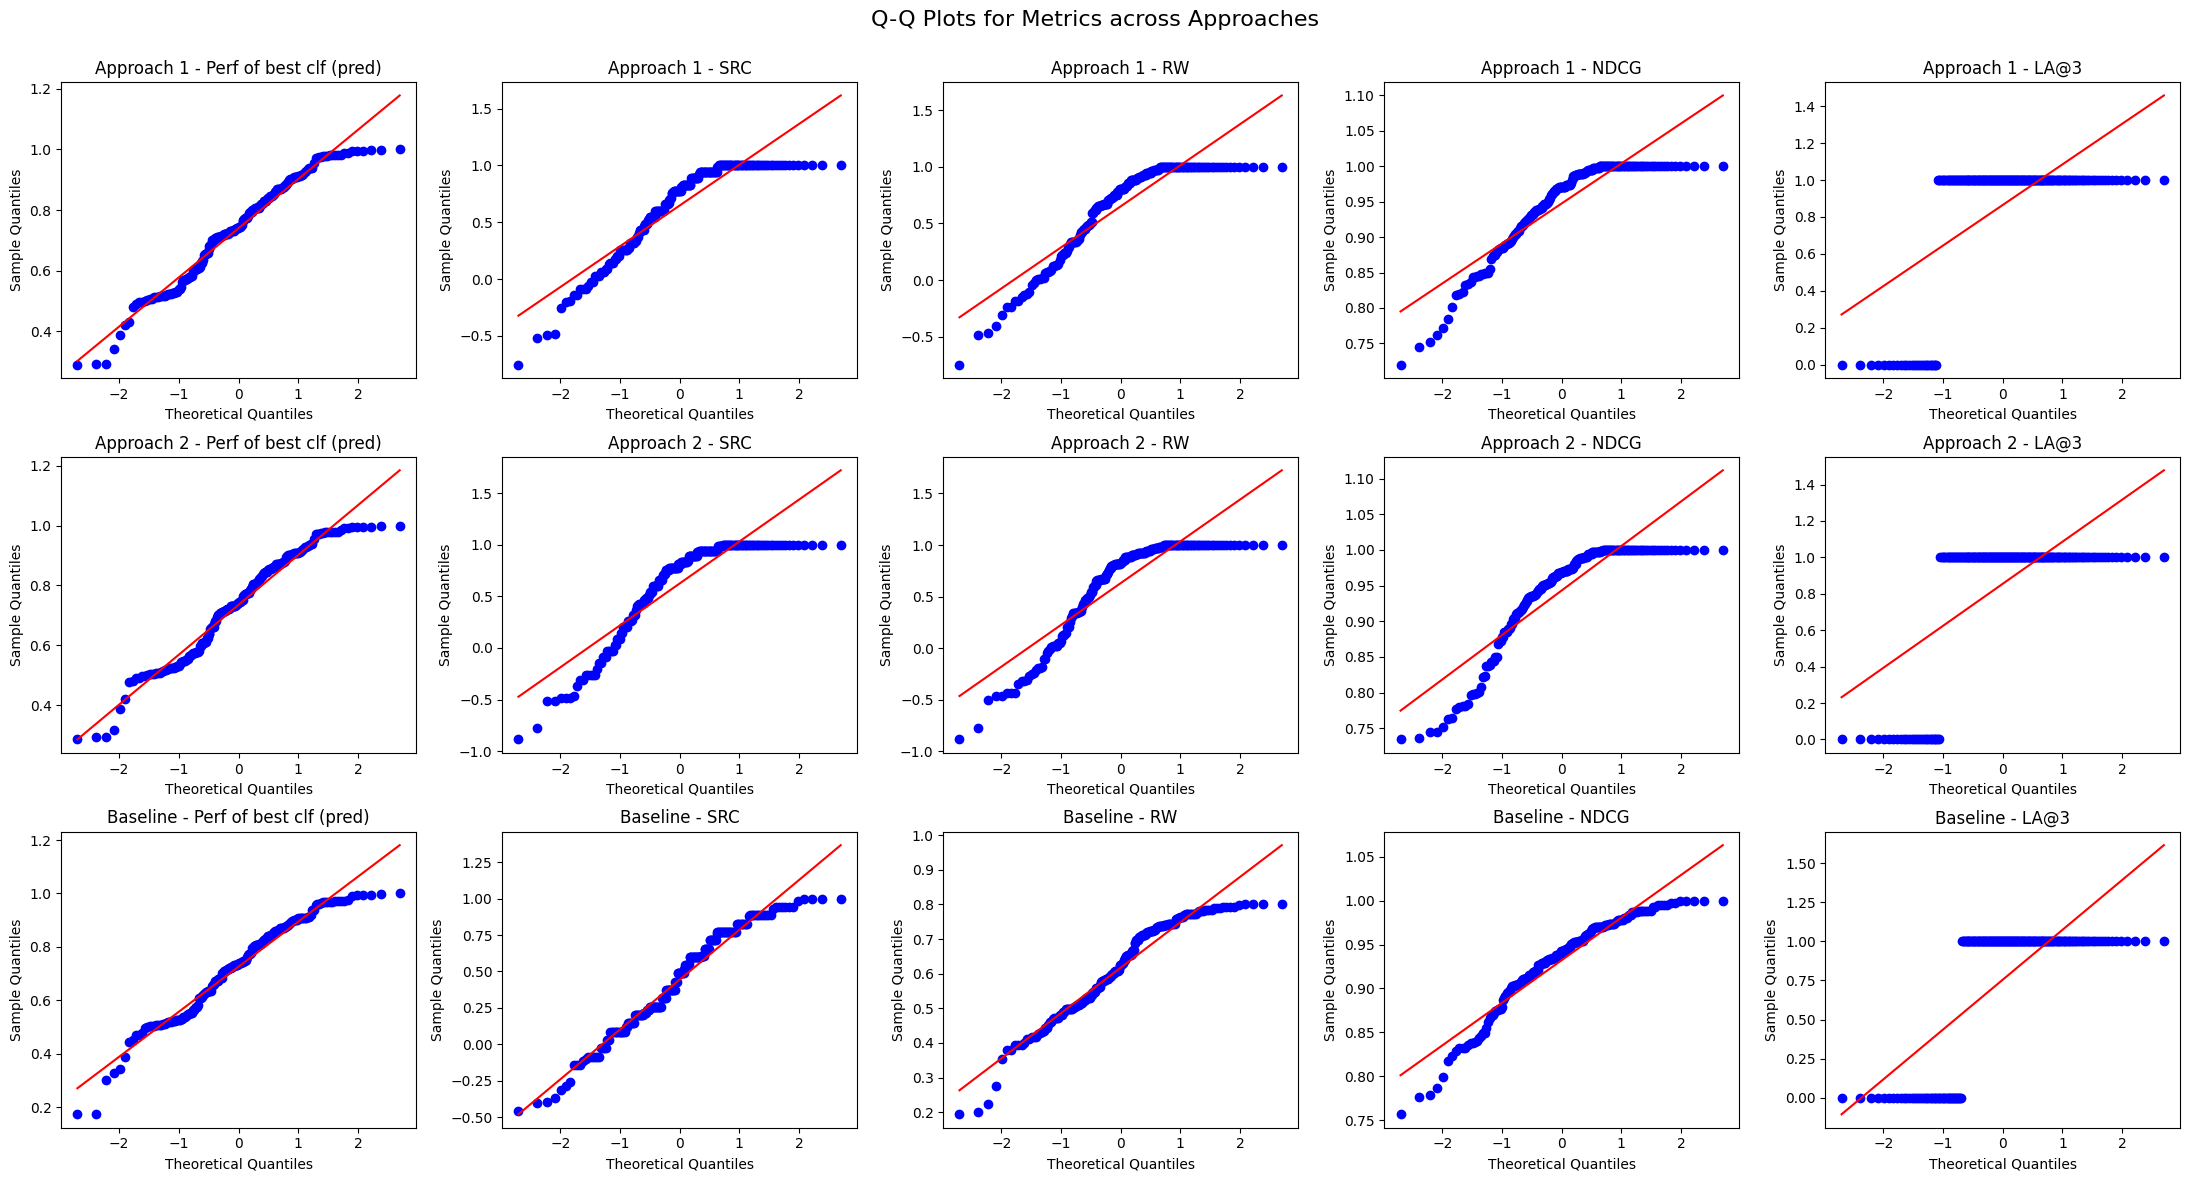

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Q-Q Plots for Metrics across Approaches', fontsize=16)

metrics_to_plot = ['Perf of best clf (pred)', 'SRC', 'RW', 'NDCG', 'LA@3']
summaries_qq = {
    'Approach 1': new_rank_ab1_summary_df,
    'Approach 2': new_rank_ab2_summary_df,
    'Baseline': new_ar_summary_df
}

for i, (approach_name, df) in enumerate(summaries_qq.items()):
    for j, metric in enumerate(metrics_to_plot):
        ax = axes[i, j]
        data = df[metric].dropna().astype(float)

        if len(data) > 0:
            stats.probplot(data, dist="norm", plot=ax)
            ax.set_title(f'{approach_name} - {metric}')
            ax.set_xlabel('Theoretical Quantiles')
            ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

In [ ]:
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_results = []
metrics_to_test = ['Perf of best clf (pred)', 'SRC', 'RW', 'NDCG', 'LA@3']

for metric in metrics_to_test:
    data_ab1 = new_rank_ab1_summary_df[metric].dropna().astype(float)
    data_ab2 = new_rank_ab2_summary_df[metric].dropna().astype(float)
    data_ar = new_ar_summary_df[metric].dropna().astype(float)

    # Since it was Leave-One-Out, arrays should be identical in length and paired correctly,
    # but we enforce the same length just as a safety measure
    min_len = min(len(data_ab1), len(data_ab2), len(data_ar))

    if min_len >= 3: # Friedman requires at least 3 samples
        stat, p_value = friedmanchisquare(data_ab1[:min_len], data_ab2[:min_len], data_ar[:min_len])
        is_significant = 'Yes' if p_value < 0.05 else 'No'

        friedman_results.append({
            'Metric': metric,
            'Friedman Statistic': round(stat, 4),
            'p-value': f"{p_value:.4e}",
            'Significant diff (p<0.05)?': is_significant
        })

friedman_df = pd.DataFrame(friedman_results)
display(friedman_df)

,Metric,Friedman Statistic,p-value,Significant diff (p<0.05)?
0,Perf of best clf (pred),19.8032,5.0094e-05,Yes
1,SRC,47.7621,4.2520e-11,Yes
2,RW,33.5007,5.3139e-08,Yes
3,NDCG,28.3053,7.1382e-07,Yes
4,LA@3,10.8293,4.4510e-03,Yes


In [ ]:
# Ensure scikit-posthocs is installed for the Nemenyi test
try:
    import scikit_posthocs as sp
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-posthocs"])
    import scikit_posthocs as sp

import numpy as np
from IPython.display import display

metrics_to_test = ['Perf of best clf (pred)', 'SRC', 'RW', 'NDCG', 'LA@3']
nemenyi_results = {}

for metric in metrics_to_test:
    data_ab1 = new_rank_ab1_summary_df[metric].dropna().astype(float).values
    data_ab2 = new_rank_ab2_summary_df[metric].dropna().astype(float).values
    data_ar = new_ar_summary_df[metric].dropna().astype(float).values

    min_len = min(len(data_ab1), len(data_ab2), len(data_ar))

    # Construct a 2D array: rows are blocks (datasets), columns are treatments (approaches)
    combined_data = np.array([
        data_ab1[:min_len],
        data_ab2[:min_len],
        data_ar[:min_len]
    ]).T

    # Run Nemenyi post-hoc test
    p_values = sp.posthoc_nemenyi_friedman(combined_data)

    # Rename columns and index for readability
    p_values.columns = ['Approach 1', 'Approach 2', 'Baseline']
    p_values.index = ['Approach 1', 'Approach 2', 'Baseline']

    nemenyi_results[metric] = p_values

for metric, p_vals in nemenyi_results.items():
    print(f"========== Nemenyi Post-hoc Test p-values for: {metric} ==========")
    print("Values < 0.05 indicate a statistically significant difference between the pair.")
    display(p_vals.round(4))
    print("")

========== Nemenyi Post-hoc Test p-values for: Perf of best clf (pred) ==========
Values < 0.05 indicate a statistically significant difference between the pair.


,Approach 1,Approach 2,Baseline
Approach 1,1.0000,0.3541,0.0030
Approach 2,0.3541,1.0000,0.1386
Baseline,0.0030,0.1386,1.0000



========== Nemenyi Post-hoc Test p-values for: SRC ==========
Values < 0.05 indicate a statistically significant difference between the pair.


,Approach 1,Approach 2,Baseline
Approach 1,1.0000,0.9254,0.0
Approach 2,0.9254,1.0000,0.0
Baseline,0.0000,0.0000,1.0



========== Nemenyi Post-hoc Test p-values for: RW ==========
Values < 0.05 indicate a statistically significant difference between the pair.


,Approach 1,Approach 2,Baseline
Approach 1,1.0000,0.9516,0.0
Approach 2,0.9516,1.0000,0.0
Baseline,0.0000,0.0000,1.0



========== Nemenyi Post-hoc Test p-values for: NDCG ==========
Values < 0.05 indicate a statistically significant difference between the pair.


,Approach 1,Approach 2,Baseline
Approach 1,1.0000,0.9969,0.0000
Approach 2,0.9969,1.0000,0.0001
Baseline,0.0000,0.0001,1.0000



========== Nemenyi Post-hoc Test p-values for: LA@3 ==========
Values < 0.05 indicate a statistically significant difference between the pair.


,Approach 1,Approach 2,Baseline
Approach 1,1.0000,0.9877,0.2248
Approach 2,0.9877,1.0000,0.2909
Baseline,0.2248,0.2909,1.0000


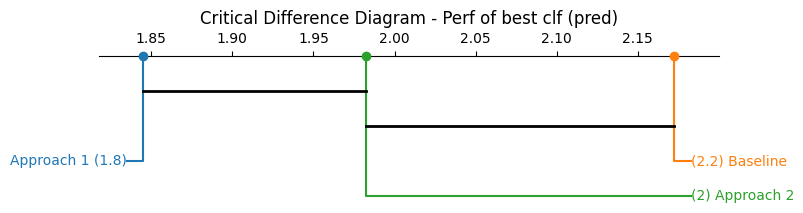

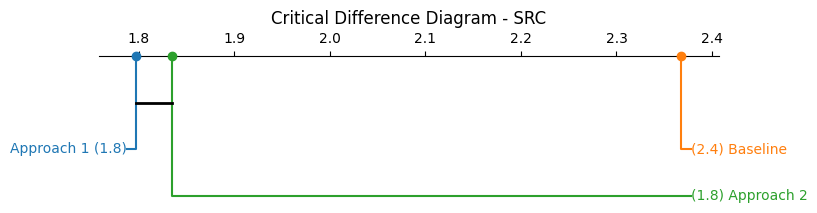

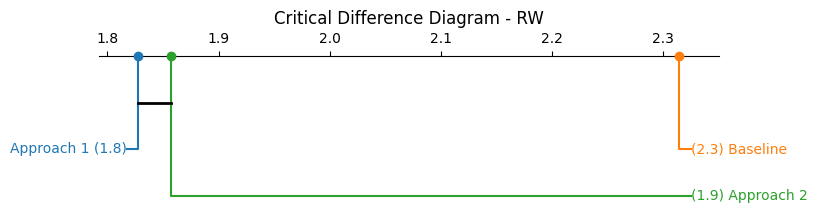

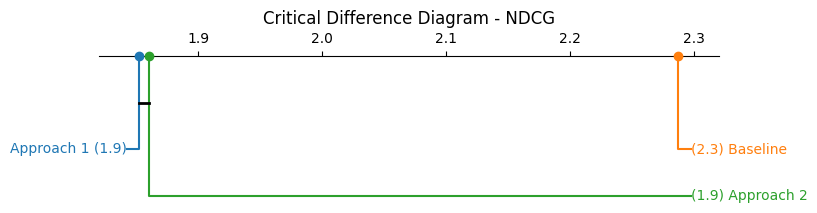

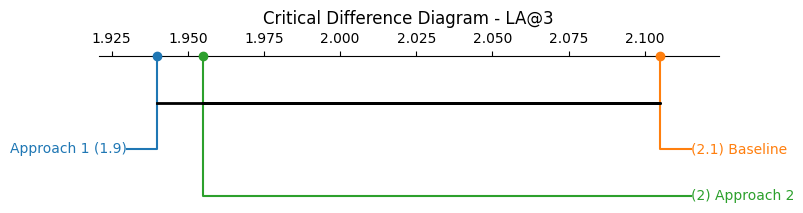

In [ ]:
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import numpy as np

# We calculate average ranks for each metric and plot the Critical Difference (CD) diagram
metrics_to_test = ['Perf of best clf (pred)', 'SRC', 'RW', 'NDCG', 'LA@3']

for metric in metrics_to_test:
    data_ab1 = new_rank_ab1_summary_df[metric].dropna().astype(float).values
    data_ab2 = new_rank_ab2_summary_df[metric].dropna().astype(float).values
    data_ar = new_ar_summary_df[metric].dropna().astype(float).values
    min_len = min(len(data_ab1), len(data_ab2), len(data_ar))

    # Rows: datasets, Columns: approaches
    combined_data = np.array([
        data_ab1[:min_len],
        data_ab2[:min_len],
        data_ar[:min_len]
    ]).T

    # Calculate ranks for this metric. Higher value is better, so we rank ascending=False
    # but scipy rankdata normally ranks smallest first. We'll just negate the data.
    from scipy.stats import rankdata
    ranks = rankdata(-combined_data, axis=1)

    # Average ranks
    avg_ranks = ranks.mean(axis=0)

    # Get Nemenyi p-values
    p_values = nemenyi_results[metric]

    # scikit-posthocs provides the critical_difference_diagram plot.
    # We pass the average ranks, the p-values dict, and the names.
    # For newer versions of scikit-posthocs, you just pass the average ranks
    # as a dict, or you can pass the ranks and sig matrix

    try:
        plt.figure(figsize=(8, 2))

        # Format the mean ranks as a pandas Series required by sp.critical_difference_diagram
        ranks_series = pd.Series(avg_ranks, index=['Approach 1', 'Approach 2', 'Baseline'])

        # Draw the CD diagram
        sp.critical_difference_diagram(ranks_series, p_values)

        plt.title(f'Critical Difference Diagram - {metric}')
        plt.show()
    except AttributeError:
        print("Your scikit-posthocs version might be too old to have `critical_difference_diagram()`. Update with `pip install -U scikit-posthocs` or stick to the sign plot!")
        break

# 14: Conclusões (Task 4)





## 14.1: Ampliação do Meta-Dataset

O experimento original utilizou apenas 22 conjuntos de dados. Para obter resultados estatisticamente mais robustos, o meta-conjunto de dados foi expandido utilizando o OpenML. Dos 6.387 conjuntos de dados ativos disponíveis, 375 atenderam aos critérios de filtragem (apenas atributos numéricos, 50–2.500 instâncias, 2–10 classes, sem valores ausentes e 2–100 atributos). Uma amostra aleatória de 200 conjuntos de dados foi extraída deste grupo.

---

## 14.2: Treinamento e Avaliação de Meta-modelos nos Novos Conjuntos de Dados

Três abordagens foram avaliadas utilizando a validação cruzada Leave-One-Out nos 200 novos conjuntos de dados:

* Abordagem 1: Regressão sobre as pontuações brutas de desempenho.

* Abordagem 2: Regressão sobre os rankings (posições).

* Baseline: Average Rank



| Metric | Approach 1 (Perf target) | Approach 2 (Rank target) | Average Rank (Baseline) |
|---|---|---|---|
| Accuracy | 0.625 | 0.545 | 0.440 |
| F1-score | 0.628 | 0.548 | 0.269 |
| Base perf | 0.740 | 0.735 | 0.726 |
| SRC | 0.647 | 0.624 | 0.443 |
| RW | 0.651 | 0.630 | 0.617 |
| NDCG | 0.947 | 0.943 | 0.932 |
| LA@3 | 0.865 | 0.855 | 0.755 |

Ambas as abordagens de meta-aprendizado superam a baseline em todas as métricas. A Abordagem 1 (regressão sobre pontuações brutas de desempenho) lidera de forma consistente, embora a margem de vantagem sobre a Abordagem 2 (regressão sobre rankings) seja pequena.

#### Box Plot - Performance Base

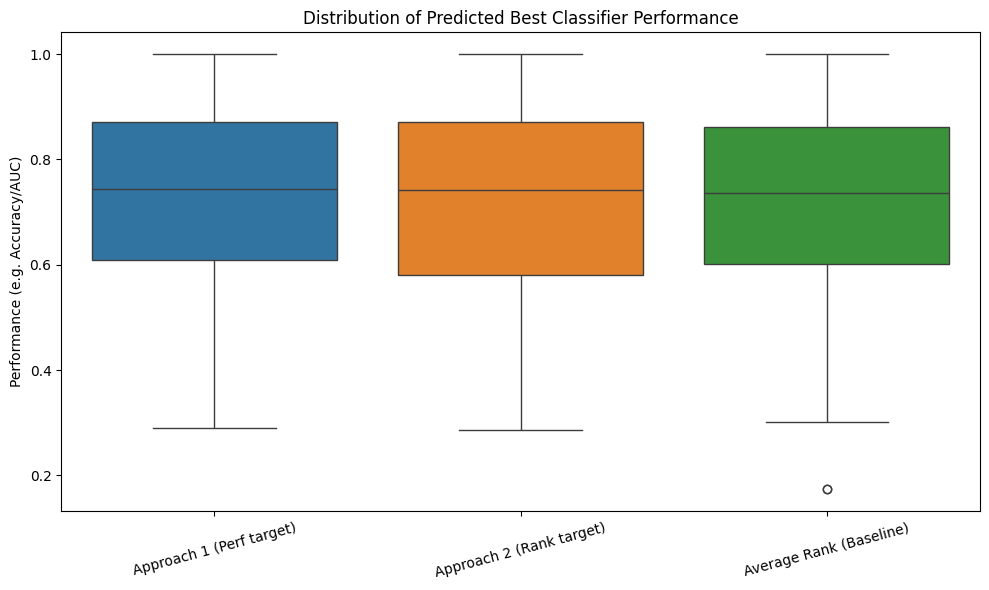

#### Mean Loss curve

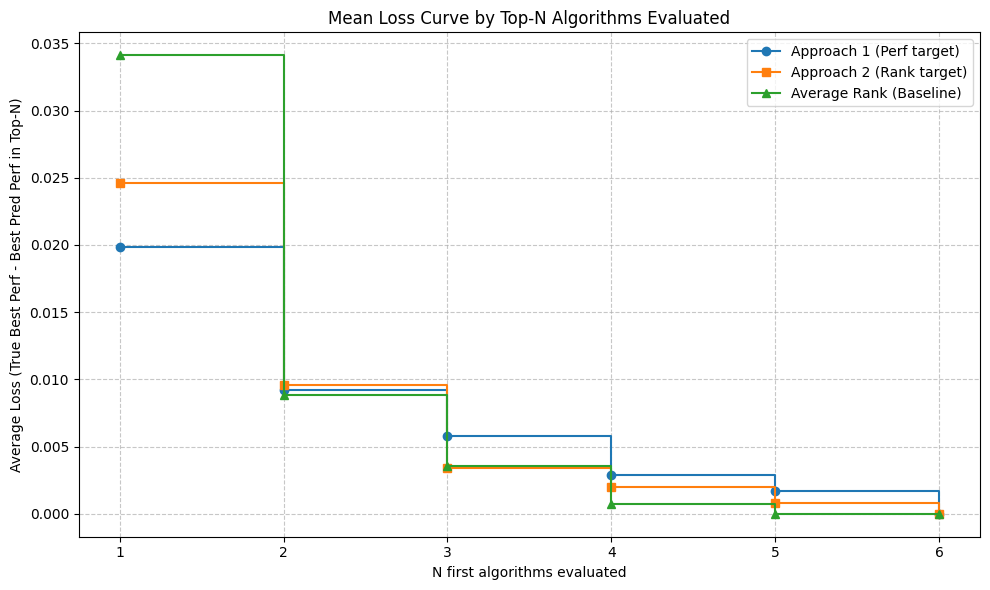

---

## 14.3: Análise Estatística

### Teste de Normalidade (Shapiro-Wilk)

Todas as métricas em todas as três abordagens foram identificadas como não normais (p<0,05), confirmando que testes não paramétricos são a escolha adequada para a comparação.

#### Q-Q Plot confirmando a não normalidade dos dados:

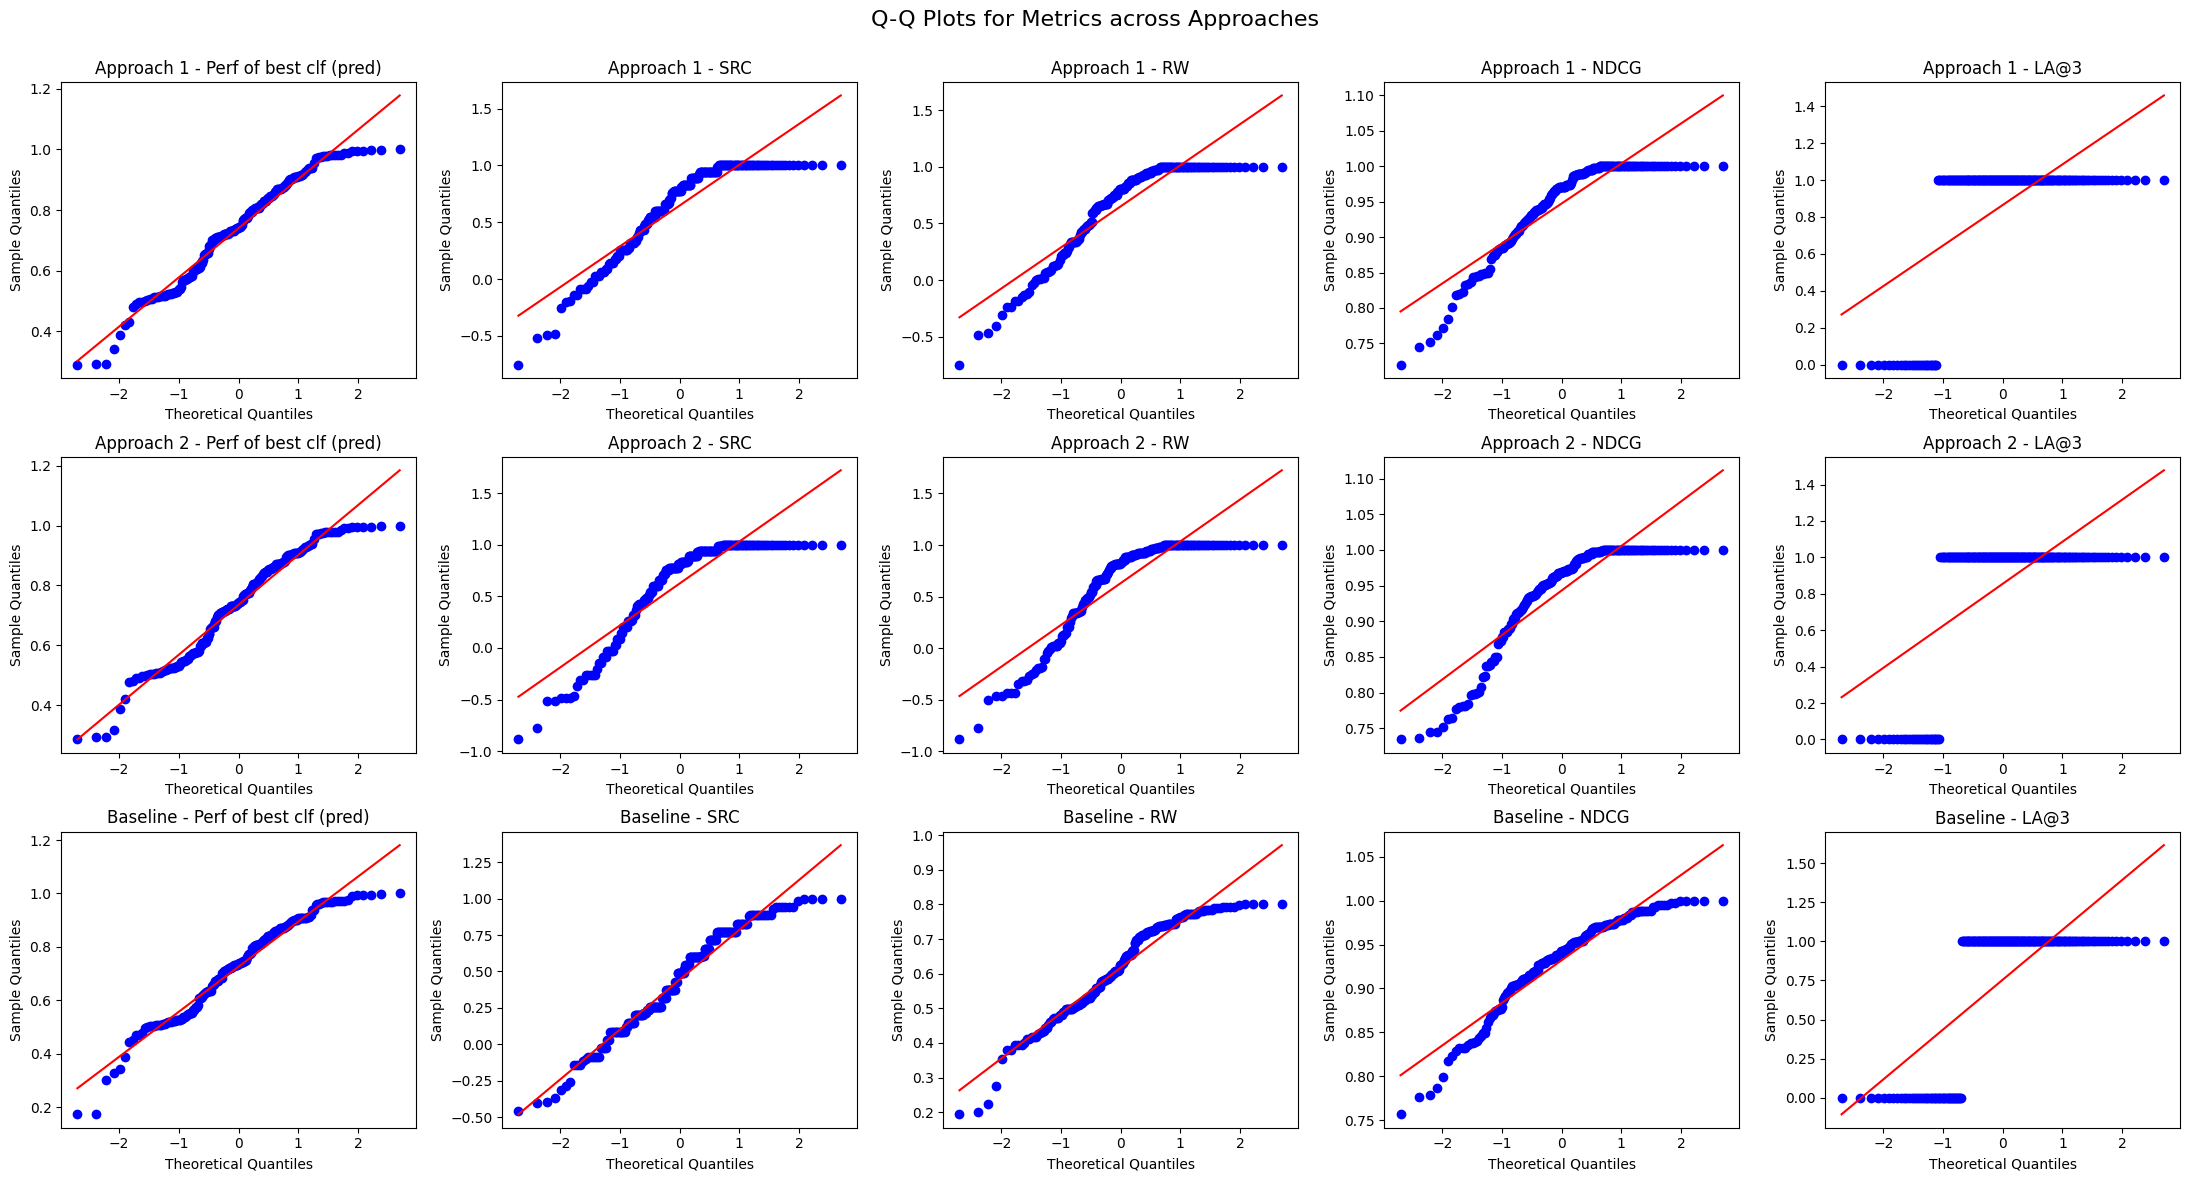

### Teste de Friedman

O teste de Friedman detectou uma diferença estatisticamente significativa entre as três abordagens para todas as cinco métricas:

| Metric | Friedman Statistic | p-value | Significant? |
|---|---|---|---|
| Perf of best clf (pred) | 19.80 | 5.01e-05 | Yes |
| SRC | 47.76 | 4.25e-11 | Yes |
| RW | 33.50 | 5.31e-08 | Yes |
| NDCG | 28.31 | 7.14e-07 | Yes |
| LA@3 | 10.83 | 4.45e-03 | Yes |

### Teste Post-hoc de Nemenyi

As comparações pareadas post-hoc revelam onde residem as diferenças significativas:

Abordagem 1 vs. Abordagem 2: Não significativa em nenhuma métrica (p>0,35 em todos os casos). As duas abordagens de meta-aprendizado são estatisticamente equivalentes, nesse conjunto de dados.

Ambas as abordagens vs. Baseline:
- **Perfomance Base**: Abordagem 1 vs. Baseline significativa (p=0,003); Abordagem 2 vs. Baseline não significativa (p=0,139).
- **SRC**, **RW**, **NDCG**: Ambas as abordagens superam significativamente a linha de base (p≈0,0).
- **LA@3**: Nenhuma das abordagens supera significativamente a linha de base (p≈0,22–0,29), apesar de o teste de Friedman ter sido significativo — o que é consistente com o conservadorismo do teste de Nemenyi e o tamanho de efeito relativamente menor para esta métrica.

Esses resultados podem ser visualizado nos Diagramas de diferença crítica

#### Perfomance Base:

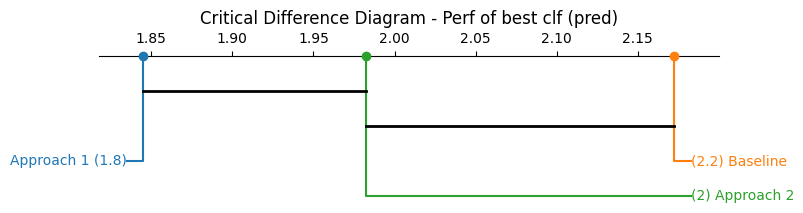

#### SRC:

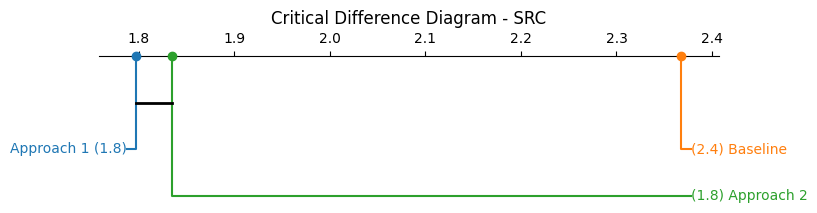

#### RW:

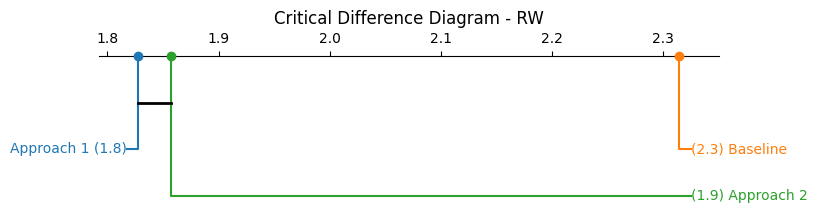

#### NDCG:
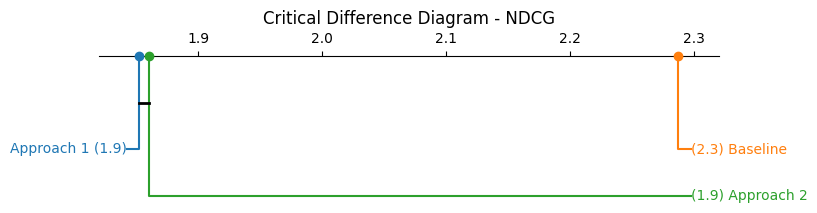

#### LA@3:

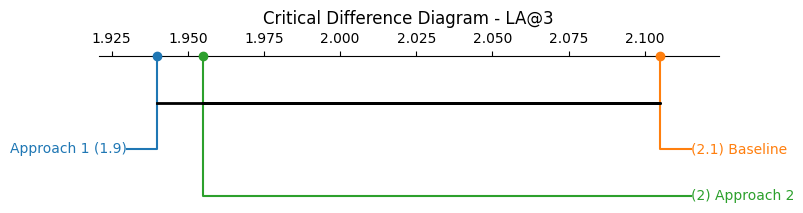

---

## 14.4: Conclusões Gerais

1. Ambas as abordagens de meta-aprendizado superam significativamente a linha de base de Ranking Médio nas principais métricas de ranking (SRC, RW, NDCG), confirmando que o uso de meta-atributos de conjuntos de dados para recomendar classificadores agrega valor em relação a uma estratégia mais simples no caso o Average Rank.

2. As Abordagens 1 e 2 são estatisticamente equivalentes em todas as métricas. Treinar o regressor diretamente sobre as pontuações brutas de desempenho (Abordagem 1) ou sobre os rankings (Abordagem 2) produz resultados indistinguíveis.

3. A Abordagem 1 é preferível na prática — ela é conceitualmente mais simples, marginalmente mais rápida de treinar e entrega resultados equivalentes ou superiores em todas as métricas.

4. **LA@3** é o diferenciador mais fraco. O teste de Friedman detectou uma diferença global, mas o teste de Nemenyi não conseguiu identificar o par responsável, sugerindo que o efeito é impulsionado pela variância em vez de uma vantagem sistemática clara.

5. A **Mean Loss Curve** confirma os achados da métrica LA@3. A análise da curva de perda mostrou que diferenças significativas entre as abordagens só aparecem ao selecionar o único algoritmo melhor classificado (N=1). A partir de N=2, as curvas convergem, o que significa que, se você estiver disposto a avaliar apenas 2 ou 3 candidatos, todas as abordagens apresentam um desempenho similarmente bom.

6. A ampliação para 200 conjuntos de dados validou e reforçou as descobertas de similiridade do experimento inicial da comparação das abordagens de ranking usando o **DecisionTreeRegressor** em 22 conjuntos, proporcionando uma confiança estatística muito maior às conclusões.